In [1]:
!pip install HuggingFace albumentations

In [2]:
import os
import cv2
import copy
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
from tqdm import tqdm
import albumentations as A
from torch.optim import AdamW
import matplotlib.pyplot as plt
from huggingface_hub import login
from transformers import AutoModel
from transformers import AutoImageProcessor
from albumentations.pytorch import ToTensorV2
from torch.cuda.amp import GradScaler, autocast
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, roc_auc_score, average_precision_score, ConfusionMatrixDisplay

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
seed=42
random.seed(seed)                   
np.random.seed(seed) 
os.environ["PYTHONHASHSEED"]=str(seed)
torch.manual_seed(seed) 
torch.cuda.manual_seed(seed) 
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False 
### controls index sampling order for WeightedRandomSampler
g=torch.Generator().manual_seed(seed)
def seed_for_dataloder_worker(w_id):
    w_seed=torch.initial_seed()%2**32
    np.random.seed(w_seed)
    random.seed(w_seed)

## 💠 **Configuration Block:**

In [5]:
### Directories
img_dir="/kaggle/input/competitions/siim-isic-melanoma-classification/jpeg/train"

### Model DINOv2 And Its ViT Variants
base_model_s = "facebook/dinov2-small" # [ViT-S/14 - 22M]
hidden_size_s=384
num_layers_s=12
base_model_b = "facebook/dinov2-base"  # [ViT-B/14 - 86M]
hidden_size_b=768
num_layers_b=12
num_register_tokens=4 
drop_rate=0.3
# for large [hidden_size=1024 , num_layers=24] , for giant [hidden_size=1536 , num_layers=40]
feature_extraction_strategies=["cls_only", # classifier input 384-dim
                               "cls_patch_mean", # classifier input 768-dim
                               "cls_patch_mean_register"] # classifier input: 1152-dim

### Data Config
img_processor = AutoImageProcessor.from_pretrained(base_model_s) # All DINov2 variants share the same mean/std 
# HuggingFace utility that loads the official preprocessing config that was used when DINOv3 was pretrained
# img_processor is Json File of { "image_mean":[0.485, 0.456, 0.406], "image_std":[0.229, 0.224, 0.225], "size":{"height": 224, "width": 224}, 
#                                 "do_resize":true, "do_normalize":true}
img_size=224
batch_size=32
num_worker_dataloder=4
train_folds=5 # df_train =80% , df_val=20%
val_folds=0 # For Validation

### Weights For Loss Functions
class_weights_CEL=[1.0, 10.0]
alpha=0.90 # Weight for positive class [set higher for imbalanced data]
gamma=2.0  # Focusing parameter [Set higher for more focus on hard examples]
reduction="mean"

### Hyperparameters [Optimizer and Scheduler]
cls_head_lr=0.00001
backbone_lr=0.00001
llrd_decay=0.9 
weight_decay=0.01
epochs=10
warmup_epochs=2
min_lr=0.000007  # minimum LR at end of cosine decay

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


## 💠 **Data Prepa For DINOv2 [Image Only]:**

In [6]:
df = pd.read_csv('/kaggle/input/competitions/siim-isic-melanoma-classification/train.csv')
df = df.drop(['benign_malignant','patient_id', 'sex', 'age_approx', 'anatom_site_general_challenge', 'diagnosis'], axis=1)

In [7]:
### StratifiedKFold for maintain the classs ratio in split [Handle Class Imbalance]
df = df.reset_index(drop=True)
df["fold"]=-1
skf=StratifiedKFold(n_splits=train_folds, shuffle=True, random_state=seed)
for fold, (train_idx, val_idx) in enumerate(skf.split(df, df.target)):
    df.loc[val_idx, "fold"]=fold
df_train=df[df.fold!=val_folds].reset_index(drop=True)
df_val=df[df.fold==val_folds].reset_index(drop=True)
print(f"Train: {len(df_train)} Where, Class 1: {df_train.target.sum()} ({df_train.target.mean()*100:.4f} %)\n"
      f"Validation: {len(df_val)} Where, Class 1: {df_val.target.sum()} ({df_val.target.mean()*100:.4f} %)\n")

Train: 26500 Where, Class 1: 467 (1.7623 %)
Validation: 6626 Where, Class 1: 117 (1.7658 %)



In [8]:
### Data augmentation pipeline for train and val data
def img_transformation(img_size, processor,split="train"):
    if split=="train":
        ### All value set depending on 224x224 Size
        return A.Compose([
            A.RandomResizedCrop(size=(img_size,img_size),scale=(0.75, 1.0),ratio=(0.9, 1.1),p=1.0),
              # scale=(0.75, 1.0) lesions are centred and it will not crop too hard
            A.HorizontalFlip(p=0.5), 
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Affine(translate_percent=0.05, scale=(0.9,1.1), rotate=(-45, 45), border_mode=0, p=0.5),
            
            ### Skin tone and lighting variation
            A.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2,hue=0.1,p=0.5),
            A.HueSaturationValue(hue_shift_limit=10,sat_shift_limit=25,val_shift_limit=15,p=0.4),
            A.RandomGamma(gamma_limit=(80,120),p=0.3),

            ### Dermoscope lighting artefacts
            A.RandomBrightnessContrast(brightness_limit=0.15,contrast_limit=0.15,p=0.4),
            A.CLAHE(clip_limit=2.0,tile_grid_size=(8,8),p=0.3),
              # enhances local contrast 

            ### Nose and blur
            A.OneOf([A.GaussNoise(noise_scale_factor=0.1, p=1.0), A.GaussianBlur(blur_limit=(3,5), p=1.0),
                     A.MotionBlur(blur_limit=5,p=1.0), A.MedianBlur(blur_limit=3, p=1.0)], p=0.3), 

            ### Dermoscope specific artefacts [simulates hair / ruler markings]
            A.CoarseDropout(num_holes_range=(4,8), hole_height_range=(8,24), hole_width_range=(8,24), fill=0, p=0.3),

            ### Normalization for DINOv3
            A.Normalize(mean=processor.image_mean, std=processor.image_std),
            ToTensorV2()])
    elif split=="val":
        return A.Compose([A.Resize(img_size, img_size), 
                         A.Normalize(mean=processor.image_mean, std=processor.image_std),
                         ToTensorV2()])

In [9]:
### Dataset class with augmention 
class prepdataset(Dataset):
  def __init__(self, df, img_dir, img_size, processor, split="train"):
    self.df=df.reset_index(drop=True)
    self.img_dir=img_dir
    self.transforms=img_transformation(img_size, processor, split)
  def __len__(self):
    return len(self.df)
  def __getitem__(self, idx):
    row=self.df.iloc[idx]
    img_path=os.path.join(self.img_dir, row.image_name + ".jpg")
    img=cv2.imread(img_path)
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img=self.transforms(image=img)["image"]
    label=torch.tensor(row.target, dtype=torch.float32)
      
    return img, label

In [10]:
train_dataset=prepdataset(df=df_train,
                          img_dir=img_dir,
                          img_size=img_size,
                          processor=img_processor, 
                          split="train")

val_dataset=prepdataset(df=df_val,
                        img_dir=img_dir,
                        img_size=img_size,
                        processor=img_processor, 
                        split="train")

In [11]:
### WeightedRandomSampler [Handle Class Imbalance]
pos_sample=(df_train.target==1).sum()
neg_sample=(df_train.target==0).sum()
pos_weights=neg_sample/pos_sample
sample_weights=df_train.target.map({1: pos_weights, 0: 1.0}).values
smaple_weights_to_tensor=torch.tensor(sample_weights, dtype=torch.float32)
weighted_sampler=WeightedRandomSampler(
    weights=smaple_weights_to_tensor,
    num_samples=len(smaple_weights_to_tensor),
    replacement=True)
print(f"Positive[melanoma]: {pos_sample}\n"
      f"Negative[benign]: {neg_sample}\n"
      f"Positive Sample Weight: {pos_weights}\n"
      f"Weighted Sampler Created With {len(smaple_weights_to_tensor)} Samples")

Positive[melanoma]: 467
Negative[benign]: 26033
Positive Sample Weight: 55.74518201284796
Weighted Sampler Created With 26500 Samples


In [12]:
### Define dataloader
train_loader=DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=weighted_sampler,
    num_workers=num_worker_dataloder,
    worker_init_fn=seed_for_dataloder_worker,
    generator=g,
    pin_memory=True)

val_loader=DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_worker_dataloder,
    pin_memory=True)

In [13]:
img, labels=next(iter(train_loader))
print(f"Train batch: {len(train_loader)}\n"
      f"Validation batch: {len(val_loader)}\n"
      f"Image batch shape: {img.shape}\n"
      f"Label batch shape: {labels.shape}\n"
      f"Positives in batch: {labels.sum().int().item()}\n"
      f"Label unique values: {labels.unique()}\n"
      f"Pixel max: {img.max():.4f}\n"
      f"Pixel min: {img.min():.4f}")

Train batch: 829
Validation batch: 208
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Positives in batch: 12
Label unique values: tensor([0., 1.])
Pixel max: 2.6400
Pixel min: -2.1179


## 💠 **Loss Function For Handle Class Imbalance:**

In [14]:
### Define Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha=alpha
        self.gamma=gamma
        self.reduction=reduction

    def forward(self, logits, targets):
        bce_loss=nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs=torch.sigmoid(logits)
        probs_true_class=targets*probs+(1-targets)*(1-probs)
        alpha_t=targets*self.alpha+(1-targets)*(1-self.alpha) # Class balancing weight
        focal_weight=alpha_t*(1-probs_true_class)**self.gamma
        focal_loss=focal_weight*bce_loss
        if self.reduction=="mean":
            return focal_loss.mean()
        elif self.reduction=="sum":
            return focal_loss.sum()
        else:
            return focal_loss

## 💠 **Define DINOv2 Model Class:**

In [15]:
class DINOv2MelanomaClassification(nn.Module):
    def __init__(self, model_variant, hidden_size, num_layers, feature_strategy, num_register_tokens, drop_rate):
        super().__init__()
        self.model_variant=model_variant 
        self.hidden_size=hidden_size 
        self.num_layers=num_layers
        self.feature_strategy=feature_strategy
        self.num_register_tokens=num_register_tokens
        self.drop_rate=drop_rate

        ### Backbone
        self.backbone=AutoModel.from_pretrained(self.model_variant )
    
        ### classifire head input based on feature_strategy
        if feature_strategy == "cls_only":
            fusion_dim=hidden_size
        elif feature_strategy=="cls_patch_mean":
            fusion_dim=hidden_size*2
        elif feature_strategy=="cls_patch_mean_register":
            fusion_dim=hidden_size*3
    
        ### define classification head
        self.classifier=nn.Sequential(
            nn.LayerNorm(fusion_dim), 
            nn.Linear(fusion_dim, 512),
            nn.GELU(),
            nn.Dropout(self.drop_rate),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(self.drop_rate),
            nn.Linear(256, 1))
        
        ### Model summary
        print(f"{'='*50}\n"
              f"DINOv2 Variant: ViT-{model_variant.split('/')[-1]}\n"
              f"Hidden Size: {hidden_size}\n"
              f"Encoder Layers: {num_layers}\n"
              f"Feature Strategy: {feature_strategy}\n"
              f"Fusion Dim: {fusion_dim}\n{'='*50}")

    def forward(self, pixel_values):
        hs =self.backbone(pixel_values=pixel_values).last_hidden_state
        cls_token=hs[:,0]

        if self.feature_strategy == "cls_only":
            fused=cls_token  # (B, hidden_size)
        elif self.feature_strategy=="cls_patch_mean":
            patch_tokens=hs[:,1+self.num_register_tokens:] # (B, 196, hidden_size)
            patch_mean=patch_tokens.mean(dim=1)            # (B, hidden_size)
            fused=torch.cat([cls_token,patch_mean], dim=1) # (B, hidden_size*2)
        elif self.feature_strategy=="cls_patch_mean_register":
            register_tokens=hs[:,1:1+self.num_register_tokens] # (B, 4, hidden_size)
            patch_tokens=hs[:,1+self.num_register_tokens:]     # (B, 196, hidden_size)
            register_mean=register_tokens.mean(dim=1)          # (B, hidden_size)
            patch_mean=patch_tokens.mean(dim=1)                # (B, hidden_size)
            fused=torch.cat([cls_token,patch_mean, register_mean], dim=1) # (B, hidden_size*3)
        return self.classifier(fused).squeeze(-1)

In [16]:
### For ViT Small
model=DINOv2MelanomaClassification(model_variant=base_model_s, 
                                   hidden_size=hidden_size_s,
                                   num_layers=num_layers_s, 
                                   feature_strategy="cls_only",
                                   num_register_tokens=num_register_tokens, 
                                   drop_rate=drop_rate).to(device)

# model=DINOv2MelanomaClassification(model_variant=base_model_s, 
#                                   hidden_size=hidden_size_s,
#                                   num_layers=num_layers_s, 
#                                   feature_strategy="cls_patch_mean",
#                                   num_register_tokens=num_register_tokens, 
#                                   drop_rate=drop_rate).to(device)

# model=DINOv2MelanomaClassification(model_variant=base_model_s, 
#                                   hidden_size=hidden_size_s,
#                                   num_layers=num_layers_s, 
#                                   feature_strategy="cls_patch_mean_register",
#                                   num_register_tokens=num_register_tokens, 
#                                   drop_rate=drop_rate).to(device)

### For ViT Base 
# model=DINOv2MelanomaClassification(model_variant=base_model_b, 
#                                   hidden_size=hidden_size_b,
#                                   num_layers=num_layers_b, 
#                                   feature_strategy="cls_only",
#                                   num_register_tokens=num_register_tokens, 
#                                   drop_rate=drop_rate).to(device)

# model=DINOv2MelanomaClassification(model_variant=base_model_b, 
#                                   hidden_size=hidden_size_b,
#                                   num_layers=num_layers_b, 
#                                   feature_strategy="cls_patch_mean",
#                                   num_register_tokens=num_register_tokens, 
#                                   drop_rate=drop_rate).to(device)

# model=DINOv2MelanomaClassification(model_variant=base_model_b, 
#                                   hidden_size=hidden_size_b,
#                                   num_layers=num_layers_b, 
#                                   feature_strategy="cls_patch_mean_register",
#                                   num_register_tokens=num_register_tokens, 
#                                   drop_rate=drop_rate).to(device)

### We can also use Large and Gaint variant like this if GPU supported 

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 Variant: ViT-dinov2-small
Hidden Size: 384
Encoder Layers: 12
Feature Strategy: cls_only
Fusion Dim: 384


## 💠 **Custom Fine Tune DINOv2 Function:**

In [17]:
def freeze_dinov2_layers(
    model,
    freeze_patch_embeddings=True,
    freeze_encoder_layers=None,
    freeze_bottom_n_layers=None,
    freeze_top_n_layers=None,
    freeze_layernorm=False,
    freeze_classifier=False):

    ### BackBone Could be [ViT-S/14 - 22M] or [ViT-B/14 - 86M]
    total_layers= len(model.backbone.encoder.layer)
    
    ### For patch embeddings
    if freeze_patch_embeddings:
        for param in model.backbone.embeddings.parameters():
            param.requires_grad=False
        print("Patch Embedding Layer is Frozen.")
    else:
        for param in model.backbone.embeddings.parameters():
            param.requires_grad=True
        print("Patch Embedding Layer is Traianble.")

    ### For specific encoder layers
    if freeze_encoder_layers is not None:
        valid=[]
        invalid=[]
        for layer_num in freeze_encoder_layers:
            if layer_num <0 or layer_num>= total_layers:
                invalid.append(layer_num)
                continue
            for param in model.backbone.encoder.layer[layer_num].parameters():
                param.requires_grad=False
            valid.append(layer_num)
        if valid:
            print(f"Spesific encoder layers frozen: {valid}")
        if invalid:
            print(f"Invalid layer numbers : {invalid}, Valid range is 0 to {total_layers-1}")

    ### For bottom N layers 
    if freeze_bottom_n_layers is not None:
        freeze_bottom_n_layers=min(freeze_bottom_n_layers, total_layers)
        for layer in model.backbone.encoder.layer[:freeze_bottom_n_layers]:
          for param in layer.parameters():
            param.requires_grad=False
        print(f"Bottom {freeze_bottom_n_layers} encoder layers are Frozen From 0 to {freeze_bottom_n_layers-1}.")

    ### For Top N layers
    if freeze_top_n_layers is not None:
        freeze_top_n_layers=min(freeze_top_n_layers, total_layers)
        for layer in model.backbone.encoder.layer[-freeze_top_n_layers:]:
          for param in layer.parameters():
            param.requires_grad=False
        start=total_layers-freeze_top_n_layers
        print(f"Top {freeze_top_n_layers} encoder layers are Frozen From {start} to {total_layers-1}.")

    ### For layernorm
    if freeze_layernorm:
        for param in model.backbone.layernorm.parameters():
            param.requires_grad=False
        print("Final LayerNorm is Frozen.")
    else:
        for param in model.backbone.layernorm.parameters():
            param.requires_grad=True
        print("Final LayerNorm is Traianble.")

    ### For classification head
    if freeze_classifier:
        for param in model.classifier.parameters():
          param.requires_grad=False
        print("Classifier Head is Frozen.")
    else:
        for param in model.classifier.parameters():
          param.requires_grad=True
        print("Classifier Head is Traianble.")  

    ### Parameter summary
    total_params=sum(p.numel() for p in model.parameters())
    trainable_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params= total_params-trainable_params
    print(f"{'='*45}\n"
          f"Total Parameters     : {total_params:,}\n"
          f"Trainable Parameters : {trainable_params:,}\n"
          f"Frozen Parameters    : {frozen_params:,}\n"
          f"Trainable Percentage : {100*trainable_params/total_params:.1f}%")
    ### Layer by layer status
    print(f"{'='*45}\nLayer-by-Layer Status:\n{'='*45}")
    embedding_status="Frozen" if not any(p.requires_grad for p in model.backbone.embeddings.parameters()) else "Trainable"
    print(f"Patch Embeddings: {embedding_status}")
    for i, layer in enumerate(model.backbone.encoder.layer):
        encoder_status="Frozen" if not any(p.requires_grad for p in layer.parameters()) else "Trainable"
        print(f"Encoder Layer: {i:02d} : {encoder_status}")
    layernorm_status="Frozen" if not any(p.requires_grad for p in model.backbone.layernorm.parameters()) else "Trainable"
    print(f"Final Layernorm: {layernorm_status}")
    cls_head_status="Frozen" if not any(p.requires_grad for p in model.classifier.parameters()) else "Trainable"
    print(f"classifier Head: {cls_head_status}")

    return model

In [18]:
### Architecture 01
print(f"{'='*50}\nModel Architecture 01\n{'='*50}")
arch01_model = freeze_dinov2_layers(
                    model=copy.deepcopy(model),
                    freeze_patch_embeddings=True,
                    freeze_encoder_layers=None,
                    freeze_bottom_n_layers=None,
                    freeze_top_n_layers=None,
                    freeze_layernorm=False,
                    freeze_classifier=False)

### Architecture 02
print(f"\n{'='*50}\nModel Architecture 02\n{'='*50}")
arch02_model = freeze_dinov2_layers(
                    model=copy.deepcopy(model),
                    freeze_patch_embeddings=True,
                    freeze_encoder_layers=[0,1,2,3,4],
                    freeze_bottom_n_layers=None,
                    freeze_top_n_layers=None,
                    freeze_layernorm=False,
                    freeze_classifier=False)

### Architecture 03
print(f"\n{'='*50}\nModel Architecture 03\n{'='*50}")
arch03_model = freeze_dinov2_layers(
                    model=copy.deepcopy(model),
                    freeze_patch_embeddings=True,
                    freeze_encoder_layers=[8,9,10,11],
                    freeze_bottom_n_layers=None,
                    freeze_top_n_layers=None,
                    freeze_layernorm=False,
                    freeze_classifier=False)

Model Architecture 01
Patch Embedding Layer is Frozen.
Final LayerNorm is Traianble.
Classifier Head is Traianble.
Total Parameters     : 22,386,049
Trainable Parameters : 21,633,025
Frozen Parameters    : 753,024
Trainable Percentage : 96.6%
Layer-by-Layer Status:
Patch Embeddings: Frozen
Encoder Layer: 00 : Trainable
Encoder Layer: 01 : Trainable
Encoder Layer: 02 : Trainable
Encoder Layer: 03 : Trainable
Encoder Layer: 04 : Trainable
Encoder Layer: 05 : Trainable
Encoder Layer: 06 : Trainable
Encoder Layer: 07 : Trainable
Encoder Layer: 08 : Trainable
Encoder Layer: 09 : Trainable
Encoder Layer: 10 : Trainable
Encoder Layer: 11 : Trainable
Final Layernorm: Trainable
classifier Head: Trainable

Model Architecture 02
Patch Embedding Layer is Frozen.
Spesific encoder layers frozen: [0, 1, 2, 3, 4]
Final LayerNorm is Traianble.
Classifier Head is Traianble.
Total Parameters     : 22,386,049
Trainable Parameters : 12,756,865
Frozen Parameters    : 9,629,184
Trainable Percentage : 57.0%
L

## 💠 **Define Optimizer:**

In [19]:
def layer_wise_lr_decay_optim(
        model, 
        cls_head_lr, 
        backbone_lr,
        llrd_decay,
        weight_decay):
    param_groups=[]
    ### For classification head
    param_groups.append({
        "params":model.classifier.parameters(),
        "lr":cls_head_lr,
        "name":"classifier_head"})
    ### For final layernorm
    param_groups.append({
        "params":model.backbone.layernorm.parameters(),
        "lr":backbone_lr,
        "name":"layernorm"})
    ### For unfroze encoder layer
    unfrozen_layers=[(i, layer)
        for i, layer in enumerate(model.backbone.encoder.layer)
        if any(p.requires_grad for p in layer.parameters())]
    ### Reverse block closest to head
    for rank, (i, layer) in enumerate(reversed(unfrozen_layers)):
        lr=backbone_lr*(llrd_decay**rank)
        param_groups.append({
            "params":layer.parameters(),
            "lr":lr,
            "name":f"encoder_layer_{i:02d}"})

    optim=AdamW(param_groups, weight_decay=weight_decay)
    print(f"{'='*50}\nOptimizer LR per Group:\n{'='*50}")
    for g in optim.param_groups:
        print(f"{g['name']:<25} : lr = {g['lr']:.2e}")
    print(f"{'='*50}\n")

    return optim 

In [20]:
### optim for architecture 01
print(f"{'='*50}\nFor Model Architecture 01")
arch01_optim = layer_wise_lr_decay_optim(
                model=arch01_model, 
                cls_head_lr=cls_head_lr, 
                backbone_lr=backbone_lr,
                llrd_decay=llrd_decay,
                weight_decay=weight_decay)

### optim for architecture 02
print(f"{'='*50}\nFor Model Architecture 02")
arch02_optim = layer_wise_lr_decay_optim(
                model=arch02_model, 
                cls_head_lr=cls_head_lr, 
                backbone_lr=backbone_lr,
                llrd_decay=llrd_decay,
                weight_decay=weight_decay)

### optim for architecture 03
print(f"{'='*50}\nFor Model Architecture 03")
arch03_optim = layer_wise_lr_decay_optim(
                model=arch03_model, 
                cls_head_lr=cls_head_lr, 
                backbone_lr=backbone_lr,
                llrd_decay=llrd_decay,
                weight_decay=weight_decay)

For Model Architecture 01
Optimizer LR per Group:
classifier_head           : lr = 1.00e-05
layernorm                 : lr = 1.00e-05
encoder_layer_11          : lr = 1.00e-05
encoder_layer_10          : lr = 9.00e-06
encoder_layer_09          : lr = 8.10e-06
encoder_layer_08          : lr = 7.29e-06
encoder_layer_07          : lr = 6.56e-06
encoder_layer_06          : lr = 5.90e-06
encoder_layer_05          : lr = 5.31e-06
encoder_layer_04          : lr = 4.78e-06
encoder_layer_03          : lr = 4.30e-06
encoder_layer_02          : lr = 3.87e-06
encoder_layer_01          : lr = 3.49e-06
encoder_layer_00          : lr = 3.14e-06

For Model Architecture 02
Optimizer LR per Group:
classifier_head           : lr = 1.00e-05
layernorm                 : lr = 1.00e-05
encoder_layer_11          : lr = 1.00e-05
encoder_layer_10          : lr = 9.00e-06
encoder_layer_09          : lr = 8.10e-06
encoder_layer_08          : lr = 7.29e-06
encoder_layer_07          : lr = 6.56e-06
encoder_layer_06 

## 💠 **Define Scheduler:**

In [21]:
def custom_scheduler(optimizer,
              epochs,
              warmup_epochs,
              min_lr,
              steps_per_epoch=None):
    warmup_steps=warmup_epochs*steps_per_epoch
    cosine_steps=(epochs-warmup_epochs)*steps_per_epoch
    warmup_scheduler=LinearLR(
        optimizer,
        start_factor = 0.1,    # starts at 10% of base LR
        end_factor   = 1.0,    # ramps to full LR
        total_iters  = warmup_steps)
    cosine_scheduler=CosineAnnealingLR(
        optimizer,
        T_max=cosine_steps,
        eta_min=min_lr)
    scheduler=SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[warmup_steps])
    print(f"{'='*50}\nScheduler:\n"
          f"Total Epochs : {epochs}\n"
          f"Warmup Epochs : {warmup_epochs} ({warmup_steps} steps)\n"
          f"Cosine Epochs : {epochs-warmup_epochs} ({cosine_steps} steps)\n"
          f"Eta Min : {min_lr:.2e}\n{'='*50}")
    return scheduler

In [22]:
### scheduler for architecture 01
print(f"{'='*50}\nFor Model Architecture 01")
arch01_scheduler = custom_scheduler(optimizer=arch01_optim,
                             epochs=epochs,
                             warmup_epochs=warmup_epochs,
                             min_lr=min_lr,
                             steps_per_epoch=len(train_loader))

### scheduler for architecture 02
print(f"{'='*50}\nFor Model Architecture 02")
arch02_scheduler = custom_scheduler(optimizer=arch02_optim,
                             epochs=epochs,
                             warmup_epochs=warmup_epochs,
                             min_lr=min_lr,
                             steps_per_epoch=len(train_loader))

### scheduler for architecture 03
print(f"{'='*50}\nFor Model Architecture 03")
arch03_scheduler = custom_scheduler(optimizer=arch03_optim,
                             epochs=epochs,
                             warmup_epochs=warmup_epochs,
                             min_lr=min_lr,
                             steps_per_epoch=len(train_loader))

For Model Architecture 01
Scheduler:
Total Epochs : 10
Warmup Epochs : 2 (1658 steps)
Cosine Epochs : 8 (6632 steps)
Eta Min : 7.00e-06
For Model Architecture 02
Scheduler:
Total Epochs : 10
Warmup Epochs : 2 (1658 steps)
Cosine Epochs : 8 (6632 steps)
Eta Min : 7.00e-06
For Model Architecture 03
Scheduler:
Total Epochs : 10
Warmup Epochs : 2 (1658 steps)
Cosine Epochs : 8 (6632 steps)
Eta Min : 7.00e-06


## 💠 **Define Evaluation Function:**

In [23]:
### Selection score function
def selection_score(recall_cls_1,
                    recall_cls_0, 
                    gap_penalty=0.5):
    if recall_cls_1<=recall_cls_0:
        return -1.0
    gap=recall_cls_1-recall_cls_0
    score=recall_cls_1-gap_penalty*gap
    return score 

In [24]:
@torch.inference_mode()
def model_evaluate(
    model,
    loader,
    device,
    threshold=0.5):
    model.eval()
    all_probs=[]
    all_labels=[]

    for imgs, labels in loader:
        imgs=imgs.to(device)
        logits=model(imgs)
        probs=torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

    all_probs=np.array(all_probs)
    all_labels=np.array(all_labels)
    all_preds=(all_probs >= threshold).astype(int)

    ### matrics
    accuracy=accuracy_score(all_labels, all_preds)
    macro_f1=f1_score(all_labels, all_preds, average="macro",zero_division=0)
    macro_prec=precision_score(all_labels, all_preds, average="macro",zero_division=0)
    macro_recall=recall_score(all_labels, all_preds, average="macro", zero_division=0)
    recall_class1=recall_score(all_labels, all_preds, pos_label=1,zero_division=0)
    recall_class0=recall_score(all_labels, all_preds, pos_label=0,zero_division=0)
    roc_auc=roc_auc_score(all_labels, all_probs)
    pr_auc=average_precision_score(all_labels, all_probs)
    gap=recall_class1 - recall_class0
    clf_report=classification_report(all_labels, all_preds, target_names=["Benign (0)", "Melanoma (1)"], zero_division=0)
    cm=confusion_matrix(all_labels, all_preds)
    
    print(f"{'='*55}\n"
          f"Accuracy: {accuracy:.4f}\n"
          f"Macro F1: {macro_f1:.4f}\n"
          f"Macro Precision: {macro_prec:.4f}\n"
          f"Macro Recall: {macro_recall:.4f}\n"
          f"Recall Class 0: {recall_class0:.4f} (Benign)\n"
          f"Recall Class 1: {recall_class1:.4f} (Melanoma)\n"
          f"Recall Gap: {gap:+.4f} (Class1 - Class0)\n"
          f"ROC-AUC: {roc_auc:.4f}\n"
          f"PR-AUC: {pr_auc:.4f}\n"
          f"\nClassification Report:\n{clf_report}")

    ### Confusion Matrix Plot 
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels=["Benign (0)", "Melanoma (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return accuracy, macro_f1, macro_prec, macro_recall, recall_class0, recall_class1, gap, roc_auc, pr_auc, cm

## 💠 **Define Early Stopping Class:**

In [25]:
class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.0001, mode="max", verbose=True):
        self.patience=patience
        self.min_delta=min_delta
        self.mode=mode
        self.verbose=verbose
        self.counter=0
        self.best_score=None
        self.stop=False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score=score
            return
        if self.mode=="max":
            improved=score>=self.best_score+self.min_delta
        else:
            improved=score<=self.best_score-self.min_delta
        if improved:
            self.best_score=score
            self.counter=0
        else:
            self.counter+=1
            if self.verbose:
                print(f"EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True

## 💠 **Define Model Check Points Class:**

In [26]:
class ModelCheckPoint:
    def __init__(self, save_path, mode="max", verbose = True):
        self.save_path=save_path
        self.mode=mode
        self.verbose=verbose
        self.best_score=None
    def __call__(self, score, model, epoch, optimizer, scheduler):
        improved =(self.best_score is None or (self.mode == "max" and score > self.best_score) or 
                  (self.mode == "min" and score < self.best_score))
        if improved:
            self.best_score = score
            torch.save({"epoch": epoch,
                        "model_state": model.state_dict(),
                        "optimizer_state": optimizer.state_dict(),
                        "scheduler_state": scheduler.state_dict(),
                        "best_score": self.best_score,}, self.save_path)
            if self.verbose:
                print(f"Checkpoint saved with score: {self.best_score:.4f} at epoch {epoch+1}")

In [27]:
### make dir
os.makedirs("/kaggle/working/arch01_checkpoint_img_only", exist_ok=True)
os.makedirs("/kaggle/working/arch02_checkpoint_img_only", exist_ok=True)
os.makedirs("/kaggle/working/arch03_checkpoint_img_only", exist_ok=True)

In [28]:
checkpoint_arch01= ModelCheckPoint(save_path="/kaggle/working/arch01_checkpoint_img_only/best_dinov2s_melanoma_img_only.pth", mode="max",verbose = True)
checkpoint_arch02= ModelCheckPoint(save_path="/kaggle/working/arch02_checkpoint_img_only/best_dinov2s_melanoma_img_only.pth", mode="max",verbose = True)
checkpoint_arch03= ModelCheckPoint(save_path="/kaggle/working/arch03_checkpoint_img_only/best_dinov2s_melanoma_img_only.pth", mode="max",verbose = True)

## 💠 **Define Training Loop:**

In [29]:
def train_loop(
    device,
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    epochs,
    early_stopping,
    checkpoint,
    loss_type="focal_loss",
    class_weights_ce=None,
    alpha=0.9,
    gamma=2.0,
    reduction="mean",
    threshold=0.3,
    gap_penalty=0.5):

    assert loss_type in ("focal_loss", "weighted_CE"), \
        f"Invalid loss_type '{loss_type}'. Choose 'focal_loss' or 'weighted_CE'."
    print(f"Loss Type: {'FocalLoss' if loss_type=='focal_loss' else 'Weighted CE'}")

    if loss_type == "focal_loss":
        criterion = FocalLoss(alpha=alpha, gamma=gamma, reduction=reduction)
    elif loss_type == "weighted_CE":
        pos_weight = torch.tensor([class_weights_ce[1] / class_weights_ce[0]], dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    scaler=GradScaler()
    results={"train_loss":[],
             "train_accuracy":[],
             "val_accuracy":[],
             "val_macro_f1":[],
             "val_macro_precision":[],
             "val_macro_recall":[],
             "val_class_0_recall":[],
             "val_class_1_recall":[],
             "val_gap":[],
             "val_roc_auc":[],
             "val_pr_auc":[],
             "selection_score":[]}

    for epoch in range(epochs):
        model.train()
        total_loss=0
        correct=0
        total_samples=0
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            imgs, labels=imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast():
                logits=model(imgs)
                
                if loss_type=="focal_loss":
                    loss=criterion(logits, labels)
                    preds=(torch.sigmoid(logits)>= threshold).long()
                elif loss_type=="weighted_CE":
                    loss=criterion(logits.squeeze(), labels.float()) 
                    preds=(torch.sigmoid(logits.squeeze()) >= threshold).long()         
                    
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            total_loss+=loss.item()
            correct+=(preds==labels.long()).sum().item()
            total_samples+=labels.size(0)
        
        avg_loss=total_loss/len(train_loader)
        train_accuracy=correct/total_samples

        print(f"\n{'='*55}\nEpoch {epoch+1:02d}/{epochs} — Validation\n{'='*55}")
        (accuracy, macro_f1, macro_precision, macro_recall,
         cls_0_recall, cls_1_recall, gap_recall, roc_auc,
         pr_auc, cm)=model_evaluate(model=model, loader=val_loader, device=device, threshold = threshold)
        monitor=selection_score(cls_1_recall,cls_0_recall,gap_penalty)

        print(f"Train Loss: {avg_loss:.4f} | Train Accuracy : {train_accuracy:.4f} | Monitor Score: {monitor:.4f}")
        results["train_loss"].append(avg_loss)
        results["train_accuracy"].append(train_accuracy)
        results["val_accuracy"].append(accuracy)
        results["val_macro_f1"].append(macro_f1)
        results["val_macro_precision"].append(macro_precision)
        results["val_macro_recall"].append(macro_recall)
        results["val_class_0_recall"].append(cls_0_recall)
        results["val_class_1_recall"].append(cls_1_recall)
        results["val_gap"].append(gap_recall)
        results["val_roc_auc"].append(roc_auc)
        results["val_pr_auc"].append(pr_auc)
        results["selection_score"].append(monitor)

        checkpoint(monitor, model, epoch, optimizer, scheduler)
        early_stopping(monitor)
        if early_stopping.stop:
            print(f"\nEarly Stopping Triggered At Epoch {epoch+1}")
            break

    return results

## 💠 **Fine Tune DINOv2 [ViT-S/14 - 22M]:**

#### **Architecture 01:**

/tmp/ipykernel_58/508362579.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler()


Loss Type: FocalLoss


Epoch 1/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/10 [Train]: 100%|██████████| 829/829 [15:02<00:00,  1.09s/it]


Epoch 01/10 — Validation


Accuracy: 0.6385
Macro F1: 0.4311
Macro Precision: 0.5227
Macro Recall: 0.8076
Recall Class 0: 0.6324 (Benign)
Recall Class 1: 0.9829 (Melanoma)
Recall Gap: +0.3506 (Class1 - Class0)
ROC-AUC: 0.9074
PR-AUC: 0.1659

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.63      0.77      6509
Melanoma (1)       0.05      0.98      0.09       117

    accuracy                           0.64      6626
   macro avg       0.52      0.81      0.43      6626
weighted avg       0.98      0.64      0.76      6626



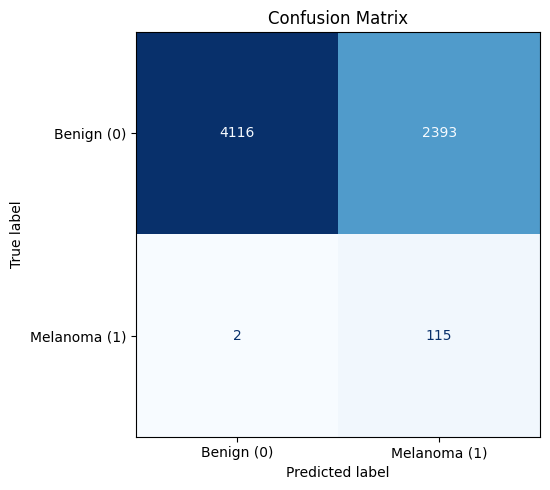

Train Loss: 0.0322 | Train Accuracy : 0.6720 | Monitor Score: 0.8076
Checkpoint saved with score: 0.8076 at epoch 1


Epoch 2/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 2/10 [Train]: 100%|██████████| 829/829 [15:36<00:00,  1.13s/it]


Epoch 02/10 — Validation


Accuracy: 0.7757
Macro F1: 0.4971
Macro Precision: 0.5317
Macro Recall: 0.8313
Recall Class 0: 0.7737 (Benign)
Recall Class 1: 0.8889 (Melanoma)
Recall Gap: +0.1152 (Class1 - Class0)
ROC-AUC: 0.9117
PR-AUC: 0.2504

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.77      0.87      6509
Melanoma (1)       0.07      0.89      0.12       117

    accuracy                           0.78      6626
   macro avg       0.53      0.83      0.50      6626
weighted avg       0.98      0.78      0.86      6626



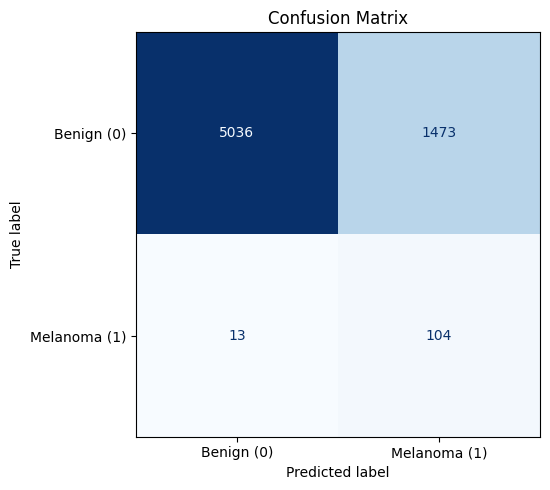

Train Loss: 0.0212 | Train Accuracy : 0.8418 | Monitor Score: 0.8313
Checkpoint saved with score: 0.8313 at epoch 2


Epoch 3/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 3/10 [Train]: 100%|██████████| 829/829 [14:28<00:00,  1.05s/it]


Epoch 03/10 — Validation


Accuracy: 0.8485
Macro F1: 0.5379
Macro Precision: 0.5421
Macro Recall: 0.8305
Recall Class 0: 0.8491 (Benign)
Recall Class 1: 0.8120 (Melanoma)
Recall Gap: -0.0372 (Class1 - Class0)
ROC-AUC: 0.9206
PR-AUC: 0.2469

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.85      0.92      6509
Melanoma (1)       0.09      0.81      0.16       117

    accuracy                           0.85      6626
   macro avg       0.54      0.83      0.54      6626
weighted avg       0.98      0.85      0.90      6626



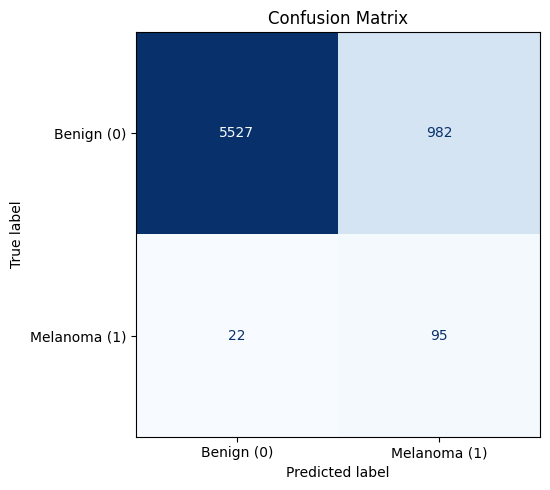

Train Loss: 0.0169 | Train Accuracy : 0.8884 | Monitor Score: -1.0000
EarlyStopping: 1/5


Epoch 4/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 4/10 [Train]: 100%|██████████| 829/829 [14:06<00:00,  1.02s/it]


Epoch 04/10 — Validation


Accuracy: 0.7160
Macro F1: 0.4679
Macro Precision: 0.5270
Macro Recall: 0.8261
Recall Class 0: 0.7119 (Benign)
Recall Class 1: 0.9402 (Melanoma)
Recall Gap: +0.2282 (Class1 - Class0)
ROC-AUC: 0.9063
PR-AUC: 0.2082

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.71      0.83      6509
Melanoma (1)       0.06      0.94      0.10       117

    accuracy                           0.72      6626
   macro avg       0.53      0.83      0.47      6626
weighted avg       0.98      0.72      0.82      6626



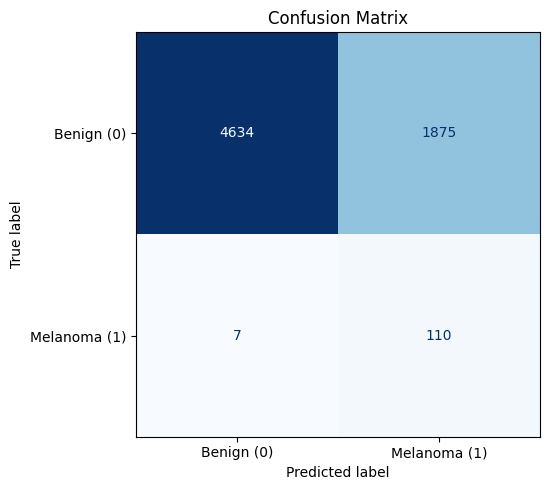

Train Loss: 0.0133 | Train Accuracy : 0.9155 | Monitor Score: 0.8261
EarlyStopping: 2/5


Epoch 5/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 5/10 [Train]: 100%|██████████| 829/829 [15:29<00:00,  1.12s/it]


Epoch 05/10 — Validation


Accuracy: 0.8545
Macro F1: 0.5352
Macro Precision: 0.5389
Macro Recall: 0.7917
Recall Class 0: 0.8568 (Benign)
Recall Class 1: 0.7265 (Melanoma)
Recall Gap: -0.1303 (Class1 - Class0)
ROC-AUC: 0.9089
PR-AUC: 0.2128

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       0.99      0.86      0.92      6509
Melanoma (1)       0.08      0.73      0.15       117

    accuracy                           0.85      6626
   macro avg       0.54      0.79      0.54      6626
weighted avg       0.98      0.85      0.91      6626



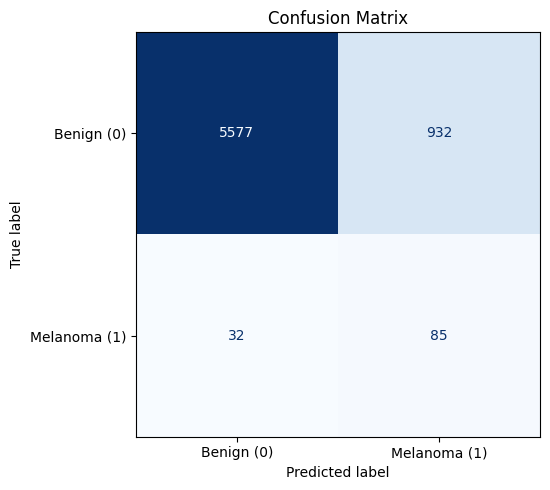

Train Loss: 0.0117 | Train Accuracy : 0.9262 | Monitor Score: -1.0000
EarlyStopping: 3/5


Epoch 6/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 6/10 [Train]: 100%|██████████| 829/829 [15:20<00:00,  1.11s/it]


Epoch 06/10 — Validation


Accuracy: 0.9094
Macro F1: 0.5781
Macro Precision: 0.5571
Macro Recall: 0.7860
Recall Class 0: 0.9140 (Benign)
Recall Class 1: 0.6581 (Melanoma)
Recall Gap: -0.2558 (Class1 - Class0)
ROC-AUC: 0.9112
PR-AUC: 0.2438

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       0.99      0.91      0.95      6509
Melanoma (1)       0.12      0.66      0.20       117

    accuracy                           0.91      6626
   macro avg       0.56      0.79      0.58      6626
weighted avg       0.98      0.91      0.94      6626



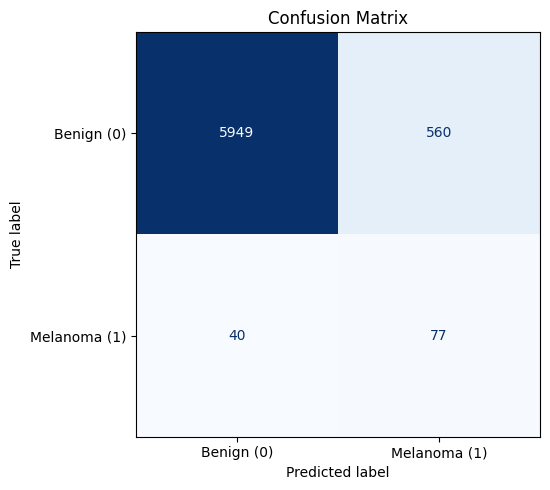

Train Loss: 0.0102 | Train Accuracy : 0.9368 | Monitor Score: -1.0000
EarlyStopping: 4/5


Epoch 7/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 7/10 [Train]: 100%|██████████| 829/829 [15:26<00:00,  1.12s/it]


Epoch 07/10 — Validation


Accuracy: 0.8566
Macro F1: 0.5419
Macro Precision: 0.5430
Macro Recall: 0.8221
Recall Class 0: 0.8579 (Benign)
Recall Class 1: 0.7863 (Melanoma)
Recall Gap: -0.0716 (Class1 - Class0)
ROC-AUC: 0.9129
PR-AUC: 0.2352

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.86      0.92      6509
Melanoma (1)       0.09      0.79      0.16       117

    accuracy                           0.86      6626
   macro avg       0.54      0.82      0.54      6626
weighted avg       0.98      0.86      0.91      6626



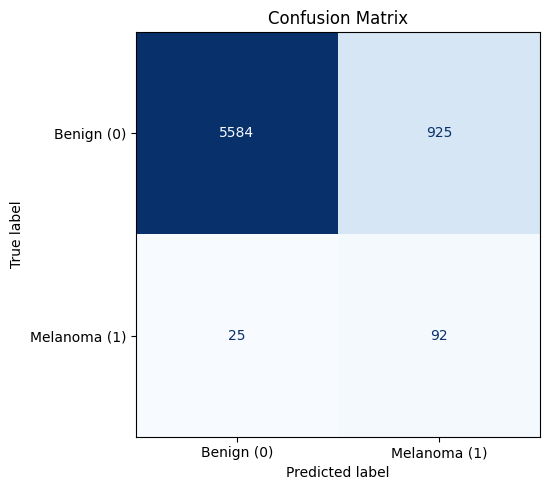

Train Loss: 0.0097 | Train Accuracy : 0.9415 | Monitor Score: -1.0000
EarlyStopping: 5/5

Early Stopping Triggered At Epoch 7


In [30]:
results_s_arch01=train_loop(device=device,
                            model=arch01_model,
                            train_loader=train_loader,
                            val_loader=val_loader,
                            optimizer=arch01_optim,
                            scheduler=arch01_scheduler,
                            epochs=epochs,
                            early_stopping=EarlyStopping(patience=5, min_delta=1e-4, mode="max"),
                            checkpoint=checkpoint_arch01,
                            loss_type="focal_loss",
                            class_weights_ce=None,
                            alpha=alpha,  
                            gamma=gamma,
                            reduction=reduction,
                            threshold=0.5,
                            gap_penalty=0.5)

#### **Architecture 02:**

/tmp/ipykernel_58/508362579.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler()


Loss Type: FocalLoss


Epoch 1/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/10 [Train]: 100%|██████████| 829/829 [15:10<00:00,  1.10s/it]


Epoch 01/10 — Validation


Accuracy: 0.7341
Macro F1: 0.4782
Macro Precision: 0.5294
Macro Recall: 0.8437
Recall Class 0: 0.7301 (Benign)
Recall Class 1: 0.9573 (Melanoma)
Recall Gap: +0.2272 (Class1 - Class0)
ROC-AUC: 0.9055
PR-AUC: 0.2058

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.73      0.84      6509
Melanoma (1)       0.06      0.96      0.11       117

    accuracy                           0.73      6626
   macro avg       0.53      0.84      0.48      6626
weighted avg       0.98      0.73      0.83      6626



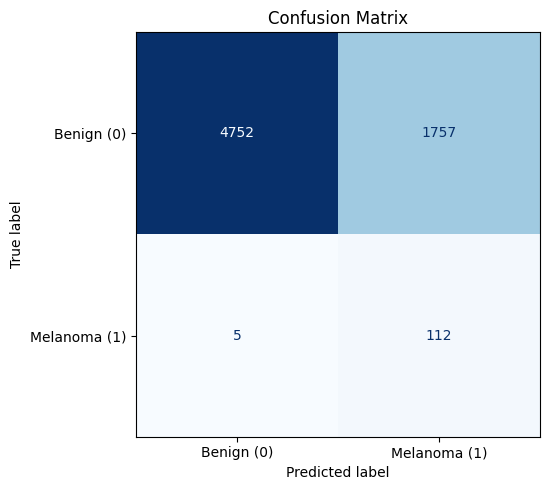

Train Loss: 0.0329 | Train Accuracy : 0.6560 | Monitor Score: 0.8437
Checkpoint saved with score: 0.8437 at epoch 1


Epoch 2/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 2/10 [Train]: 100%|██████████| 829/829 [15:05<00:00,  1.09s/it]



Epoch 02/10 — Validation
Accuracy: 0.8047
Macro F1: 0.5136
Macro Precision: 0.5359
Macro Recall: 0.8418
Recall Class 0: 0.8033 (Benign)
Recall Class 1: 0.8803 (Melanoma)
Recall Gap: +0.0770 (Class1 - Class0)
ROC-AUC: 0.9079
PR-AUC: 0.1720

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.80      0.89      6509
Melanoma (1)       0.07      0.88      0.14       117

    accuracy                           0.80      6626
   macro avg       0.54      0.84      0.51      6626
weighted avg       0.98      0.80      0.88      6626



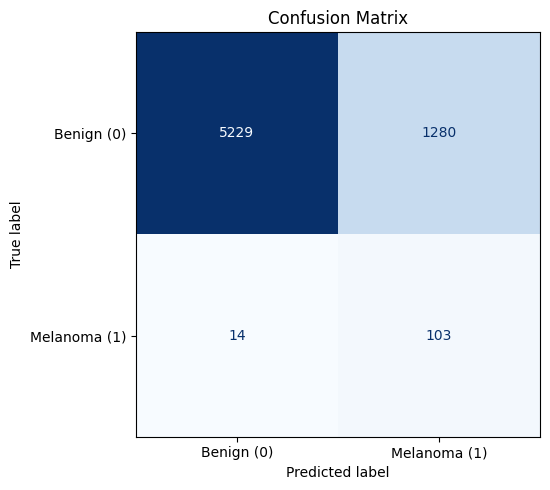

Train Loss: 0.0208 | Train Accuracy : 0.8366 | Monitor Score: 0.8418
EarlyStopping: 1/5


Epoch 3/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 3/10 [Train]: 100%|██████████| 829/829 [15:13<00:00,  1.10s/it]


Epoch 03/10 — Validation


Accuracy: 0.8118
Macro F1: 0.5151
Macro Precision: 0.5352
Macro Recall: 0.8245
Recall Class 0: 0.8113 (Benign)
Recall Class 1: 0.8376 (Melanoma)
Recall Gap: +0.0263 (Class1 - Class0)
ROC-AUC: 0.9107
PR-AUC: 0.2196

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.81      0.89      6509
Melanoma (1)       0.07      0.84      0.14       117

    accuracy                           0.81      6626
   macro avg       0.54      0.82      0.52      6626
weighted avg       0.98      0.81      0.88      6626



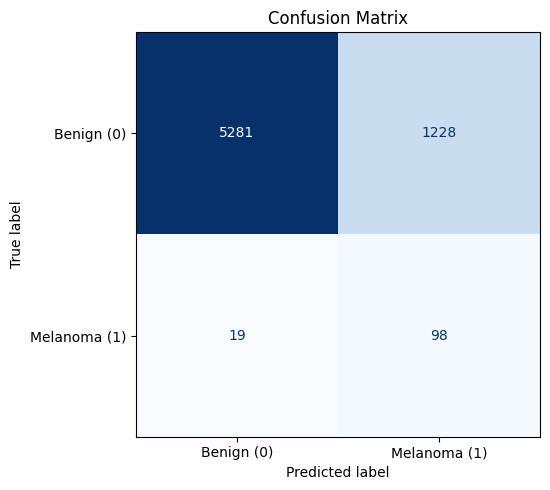

Train Loss: 0.0166 | Train Accuracy : 0.8832 | Monitor Score: 0.8245
EarlyStopping: 2/5


Epoch 4/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 4/10 [Train]: 100%|██████████| 829/829 [15:05<00:00,  1.09s/it]


Epoch 04/10 — Validation


Accuracy: 0.8479
Macro F1: 0.5304
Macro Precision: 0.5372
Macro Recall: 0.7883
Recall Class 0: 0.8501 (Benign)
Recall Class 1: 0.7265 (Melanoma)
Recall Gap: -0.1236 (Class1 - Class0)
ROC-AUC: 0.8932
PR-AUC: 0.2115

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       0.99      0.85      0.92      6509
Melanoma (1)       0.08      0.73      0.14       117

    accuracy                           0.85      6626
   macro avg       0.54      0.79      0.53      6626
weighted avg       0.98      0.85      0.90      6626



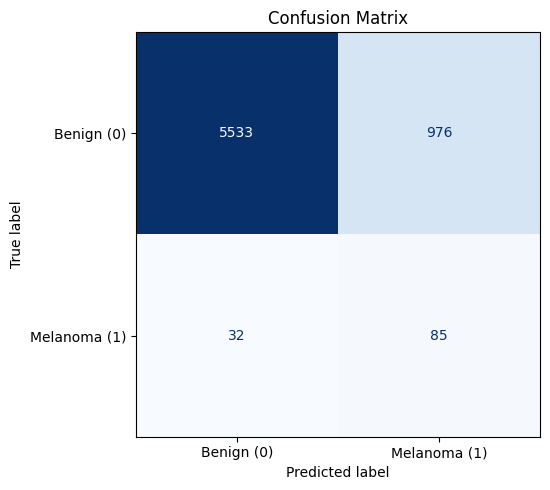

Train Loss: 0.0133 | Train Accuracy : 0.9125 | Monitor Score: -1.0000
EarlyStopping: 3/5


Epoch 5/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 5/10 [Train]: 100%|██████████| 829/829 [14:59<00:00,  1.09s/it]


Epoch 05/10 — Validation


Accuracy: 0.8704
Macro F1: 0.5491
Macro Precision: 0.5449
Macro Recall: 0.8081
Recall Class 0: 0.8726 (Benign)
Recall Class 1: 0.7436 (Melanoma)
Recall Gap: -0.1290 (Class1 - Class0)
ROC-AUC: 0.9030
PR-AUC: 0.2215

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       0.99      0.87      0.93      6509
Melanoma (1)       0.09      0.74      0.17       117

    accuracy                           0.87      6626
   macro avg       0.54      0.81      0.55      6626
weighted avg       0.98      0.87      0.92      6626



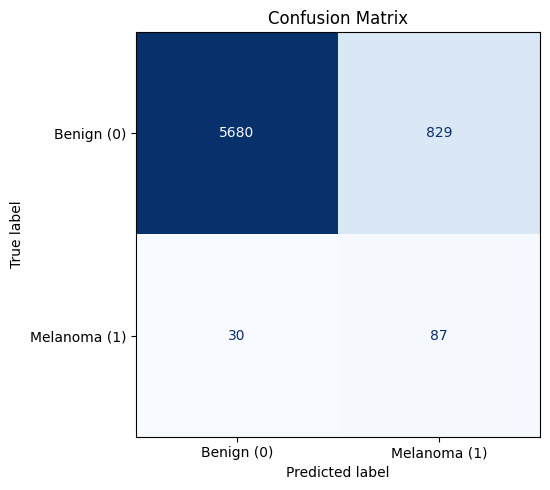

Train Loss: 0.0116 | Train Accuracy : 0.9270 | Monitor Score: -1.0000
EarlyStopping: 4/5


Epoch 6/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 6/10 [Train]: 100%|██████████| 829/829 [14:56<00:00,  1.08s/it]


Epoch 06/10 — Validation


Accuracy: 0.9174
Macro F1: 0.5694
Macro Precision: 0.5506
Macro Recall: 0.7230
Recall Class 0: 0.9246 (Benign)
Recall Class 1: 0.5214 (Melanoma)
Recall Gap: -0.4032 (Class1 - Class0)
ROC-AUC: 0.8911
PR-AUC: 0.2174

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       0.99      0.92      0.96      6509
Melanoma (1)       0.11      0.52      0.18       117

    accuracy                           0.92      6626
   macro avg       0.55      0.72      0.57      6626
weighted avg       0.98      0.92      0.94      6626



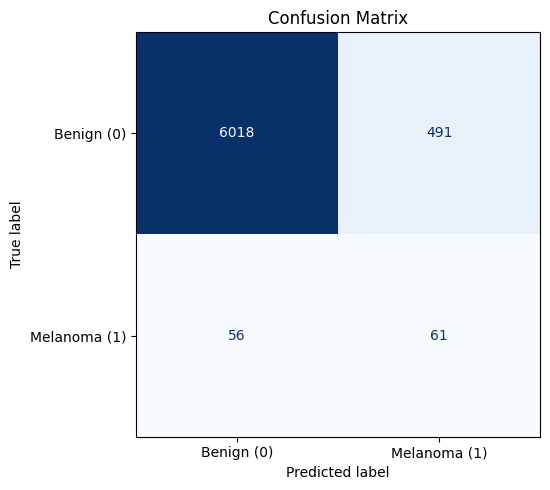

Train Loss: 0.0105 | Train Accuracy : 0.9333 | Monitor Score: -1.0000
EarlyStopping: 5/5

Early Stopping Triggered At Epoch 6


In [31]:
results_s_arch02=train_loop(device=device,
                            model=arch02_model,
                            train_loader=train_loader,
                            val_loader=val_loader,
                            optimizer=arch02_optim,
                            scheduler=arch02_scheduler,
                            epochs=epochs,
                            early_stopping=EarlyStopping(patience=5, min_delta=1e-4, mode="max"),
                            checkpoint=checkpoint_arch02,
                            loss_type="focal_loss",
                            class_weights_ce=None,
                            alpha=alpha,  
                            gamma=gamma,
                            reduction=reduction,
                            threshold=0.5,
                            gap_penalty=0.5)

#### **Architecture 03:**

/tmp/ipykernel_58/508362579.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler()


Loss Type: FocalLoss


Epoch 1/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/10 [Train]: 100%|██████████| 829/829 [15:08<00:00,  1.10s/it]


Epoch 01/10 — Validation


Accuracy: 0.4420
Macro F1: 0.3311
Macro Precision: 0.5147
Macro Recall: 0.7076
Recall Class 0: 0.4323 (Benign)
Recall Class 1: 0.9829 (Melanoma)
Recall Gap: +0.5506 (Class1 - Class0)
ROC-AUC: 0.8834
PR-AUC: 0.1320

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.43      0.60      6509
Melanoma (1)       0.03      0.98      0.06       117

    accuracy                           0.44      6626
   macro avg       0.51      0.71      0.33      6626
weighted avg       0.98      0.44      0.59      6626



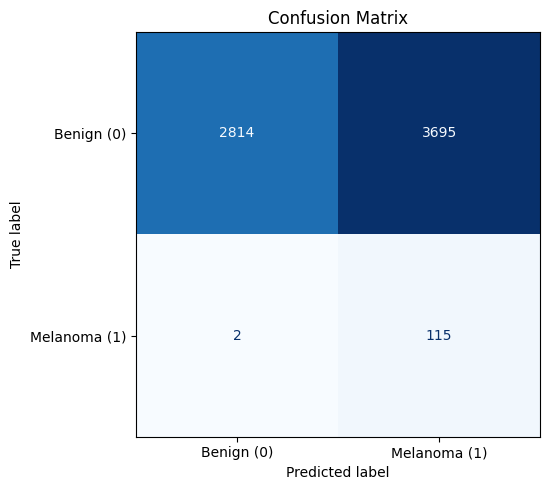

Train Loss: 0.0381 | Train Accuracy : 0.6015 | Monitor Score: 0.7076
Checkpoint saved with score: 0.7076 at epoch 1


Epoch 2/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 2/10 [Train]: 100%|██████████| 829/829 [15:04<00:00,  1.09s/it]


Epoch 02/10 — Validation


Accuracy: 0.5967
Macro F1: 0.4108
Macro Precision: 0.5207
Macro Recall: 0.7905
Recall Class 0: 0.5896 (Benign)
Recall Class 1: 0.9915 (Melanoma)
Recall Gap: +0.4018 (Class1 - Class0)
ROC-AUC: 0.9102
PR-AUC: 0.1731

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.59      0.74      6509
Melanoma (1)       0.04      0.99      0.08       117

    accuracy                           0.60      6626
   macro avg       0.52      0.79      0.41      6626
weighted avg       0.98      0.60      0.73      6626



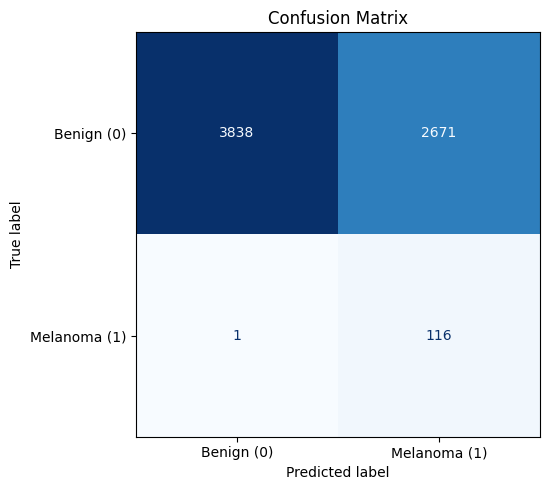

Train Loss: 0.0245 | Train Accuracy : 0.7847 | Monitor Score: 0.7905
Checkpoint saved with score: 0.7905 at epoch 2


Epoch 3/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 3/10 [Train]: 100%|██████████| 829/829 [15:01<00:00,  1.09s/it]


Epoch 03/10 — Validation


Accuracy: 0.7271
Macro F1: 0.4724
Macro Precision: 0.5270
Macro Recall: 0.8191
Recall Class 0: 0.7238 (Benign)
Recall Class 1: 0.9145 (Melanoma)
Recall Gap: +0.1908 (Class1 - Class0)
ROC-AUC: 0.8947
PR-AUC: 0.2089

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.72      0.84      6509
Melanoma (1)       0.06      0.91      0.11       117

    accuracy                           0.73      6626
   macro avg       0.53      0.82      0.47      6626
weighted avg       0.98      0.73      0.83      6626



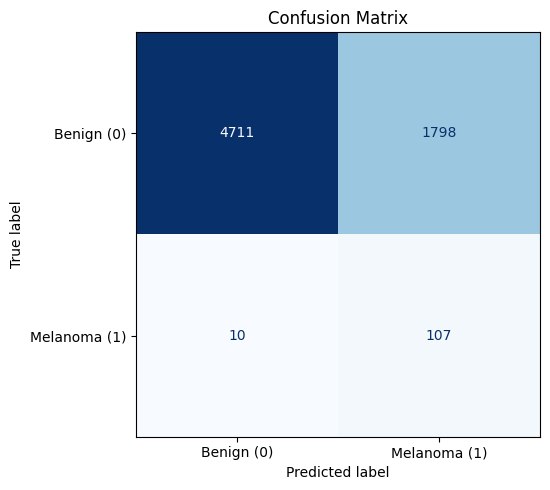

Train Loss: 0.0190 | Train Accuracy : 0.8480 | Monitor Score: 0.8191
Checkpoint saved with score: 0.8191 at epoch 3


Epoch 4/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 4/10 [Train]: 100%|██████████| 829/829 [14:52<00:00,  1.08s/it]


Epoch 04/10 — Validation


Accuracy: 0.7944
Macro F1: 0.5058
Macro Precision: 0.5330
Macro Recall: 0.8240
Recall Class 0: 0.7934 (Benign)
Recall Class 1: 0.8547 (Melanoma)
Recall Gap: +0.0613 (Class1 - Class0)
ROC-AUC: 0.9080
PR-AUC: 0.2161

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.79      0.88      6509
Melanoma (1)       0.07      0.85      0.13       117

    accuracy                           0.79      6626
   macro avg       0.53      0.82      0.51      6626
weighted avg       0.98      0.79      0.87      6626



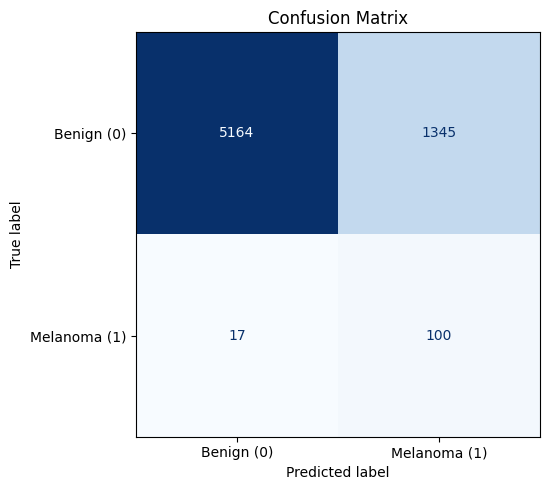

Train Loss: 0.0145 | Train Accuracy : 0.8940 | Monitor Score: 0.8240
Checkpoint saved with score: 0.8240 at epoch 4


Epoch 5/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 5/10 [Train]: 100%|██████████| 829/829 [14:55<00:00,  1.08s/it]


Epoch 05/10 — Validation


Accuracy: 0.8411
Macro F1: 0.5353
Macro Precision: 0.5420
Macro Recall: 0.8436
Recall Class 0: 0.8410 (Benign)
Recall Class 1: 0.8462 (Melanoma)
Recall Gap: +0.0052 (Class1 - Class0)
ROC-AUC: 0.9170
PR-AUC: 0.2166

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.84      0.91      6509
Melanoma (1)       0.09      0.85      0.16       117

    accuracy                           0.84      6626
   macro avg       0.54      0.84      0.54      6626
weighted avg       0.98      0.84      0.90      6626



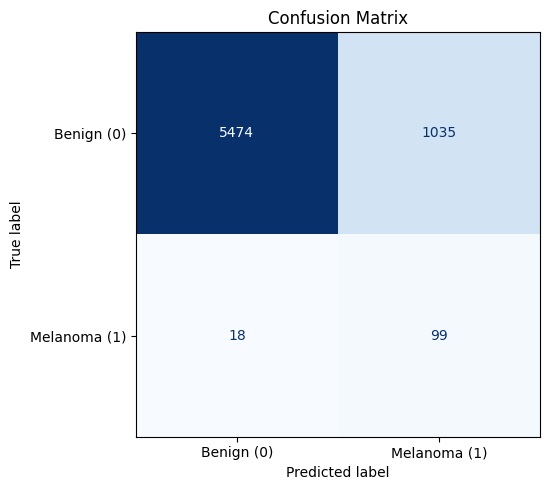

Train Loss: 0.0124 | Train Accuracy : 0.9162 | Monitor Score: 0.8436
Checkpoint saved with score: 0.8436 at epoch 5


Epoch 6/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 6/10 [Train]: 100%|██████████| 829/829 [14:45<00:00,  1.07s/it]


Epoch 06/10 — Validation


Accuracy: 0.8959
Macro F1: 0.5653
Macro Precision: 0.5508
Macro Recall: 0.7875
Recall Class 0: 0.8998 (Benign)
Recall Class 1: 0.6752 (Melanoma)
Recall Gap: -0.2246 (Class1 - Class0)
ROC-AUC: 0.9112
PR-AUC: 0.2148

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       0.99      0.90      0.94      6509
Melanoma (1)       0.11      0.68      0.19       117

    accuracy                           0.90      6626
   macro avg       0.55      0.79      0.57      6626
weighted avg       0.98      0.90      0.93      6626



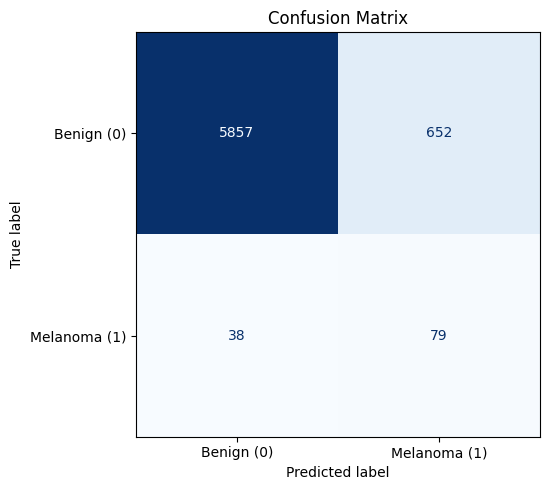

Train Loss: 0.0109 | Train Accuracy : 0.9255 | Monitor Score: -1.0000
EarlyStopping: 1/5


Epoch 7/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 7/10 [Train]: 100%|██████████| 829/829 [14:59<00:00,  1.08s/it]


Epoch 07/10 — Validation


Accuracy: 0.8649
Macro F1: 0.5477
Macro Precision: 0.5451
Macro Recall: 0.8221
Recall Class 0: 0.8665 (Benign)
Recall Class 1: 0.7778 (Melanoma)
Recall Gap: -0.0887 (Class1 - Class0)
ROC-AUC: 0.9059
PR-AUC: 0.2215

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       1.00      0.87      0.93      6509
Melanoma (1)       0.09      0.78      0.17       117

    accuracy                           0.86      6626
   macro avg       0.55      0.82      0.55      6626
weighted avg       0.98      0.86      0.91      6626



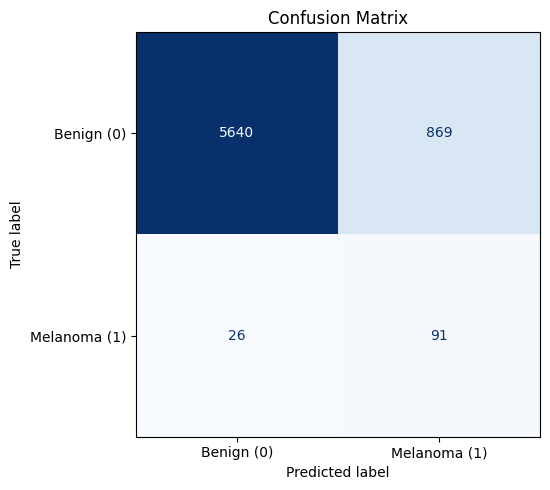

Train Loss: 0.0092 | Train Accuracy : 0.9386 | Monitor Score: -1.0000
EarlyStopping: 2/5


Epoch 8/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 8/10 [Train]: 100%|██████████| 829/829 [14:53<00:00,  1.08s/it]


Epoch 08/10 — Validation


Accuracy: 0.8731
Macro F1: 0.5489
Macro Precision: 0.5442
Macro Recall: 0.7969
Recall Class 0: 0.8759 (Benign)
Recall Class 1: 0.7179 (Melanoma)
Recall Gap: -0.1579 (Class1 - Class0)
ROC-AUC: 0.8991
PR-AUC: 0.2182

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       0.99      0.88      0.93      6509
Melanoma (1)       0.09      0.72      0.17       117

    accuracy                           0.87      6626
   macro avg       0.54      0.80      0.55      6626
weighted avg       0.98      0.87      0.92      6626



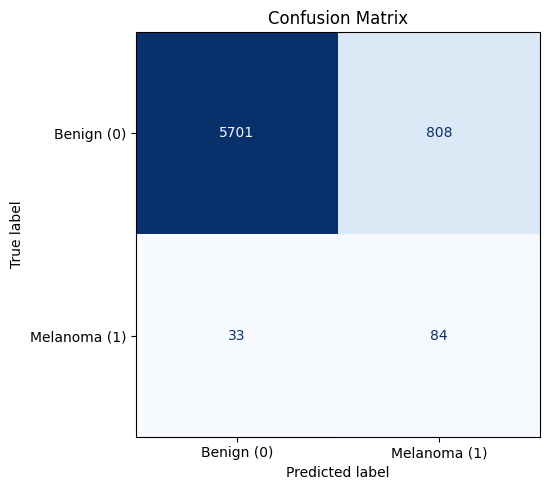

Train Loss: 0.0092 | Train Accuracy : 0.9415 | Monitor Score: -1.0000
EarlyStopping: 3/5


Epoch 9/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 9/10 [Train]: 100%|██████████| 829/829 [14:56<00:00,  1.08s/it]


Epoch 09/10 — Validation


Accuracy: 0.9182
Macro F1: 0.5857
Macro Precision: 0.5610
Macro Recall: 0.7779
Recall Class 0: 0.9233 (Benign)
Recall Class 1: 0.6325 (Melanoma)
Recall Gap: -0.2909 (Class1 - Class0)
ROC-AUC: 0.9036
PR-AUC: 0.2379

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       0.99      0.92      0.96      6509
Melanoma (1)       0.13      0.63      0.21       117

    accuracy                           0.92      6626
   macro avg       0.56      0.78      0.59      6626
weighted avg       0.98      0.92      0.94      6626



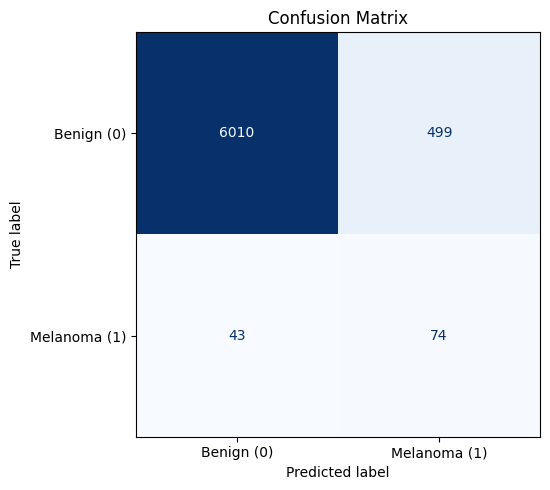

Train Loss: 0.0086 | Train Accuracy : 0.9446 | Monitor Score: -1.0000
EarlyStopping: 4/5


Epoch 10/10 [Train]:   0%|          | 0/829 [00:00<?, ?it/s]/tmp/ipykernel_58/508362579.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 10/10 [Train]: 100%|██████████| 829/829 [15:02<00:00,  1.09s/it]


Epoch 10/10 — Validation


Accuracy: 0.9105
Macro F1: 0.5783
Macro Precision: 0.5571
Macro Recall: 0.7824
Recall Class 0: 0.9152 (Benign)
Recall Class 1: 0.6496 (Melanoma)
Recall Gap: -0.2656 (Class1 - Class0)
ROC-AUC: 0.8932
PR-AUC: 0.1814

Classification Report:
              precision    recall  f1-score   support

  Benign (0)       0.99      0.92      0.95      6509
Melanoma (1)       0.12      0.65      0.20       117

    accuracy                           0.91      6626
   macro avg       0.56      0.78      0.58      6626
weighted avg       0.98      0.91      0.94      6626



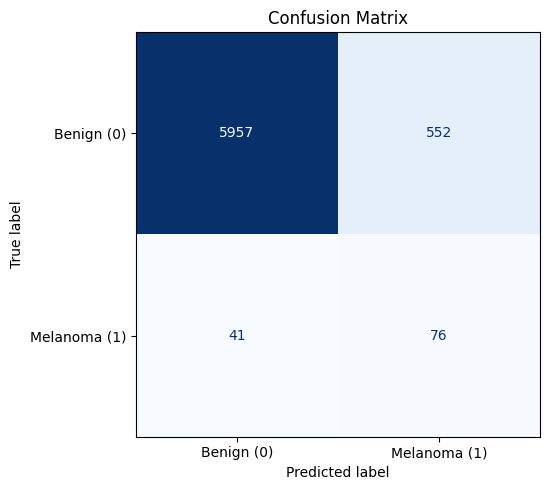

Train Loss: 0.0076 | Train Accuracy : 0.9495 | Monitor Score: -1.0000
EarlyStopping: 5/5

Early Stopping Triggered At Epoch 10


In [32]:
results_s_arch03=train_loop(device=device,
                            model=arch03_model,
                            train_loader=train_loader,
                            val_loader=val_loader,
                            optimizer=arch03_optim,
                            scheduler=arch03_scheduler,
                            epochs=epochs,
                            early_stopping=EarlyStopping(patience=5, min_delta=1e-4, mode="max"),
                            checkpoint=checkpoint_arch03,
                            loss_type="focal_loss",
                            class_weights_ce=None,
                            alpha=alpha,  
                            gamma=gamma,
                            reduction=reduction,
                            threshold=0.5,
                            gap_penalty=0.5)

## 💠 **Results Plot For [ViT-S/14 - 22M]:**

In [33]:
def plot_training_results(history, arch_name="Architecture", save_path=None):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    fig.suptitle(f"Training Results — {arch_name}", fontsize=16, fontweight="bold")
    ### Train Loss
    axes[0, 0].plot(epochs_range, history["train_loss"], color="#2E6B9E", marker="o")
    axes[0, 0].set_title("Train Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].grid(True)

    ### Train Accuracy
    axes[0, 1].plot(epochs_range, history["train_accuracy"], color="#2C7A2C", marker="o")
    axes[0, 1].set_title("Train Accuracy")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].grid(True)

    ### Val Accuracy
    axes[0, 2].plot(epochs_range, history["val_accuracy"], color="#7A2C2C", marker="o")
    axes[0, 2].set_title("Val Accuracy")
    axes[0, 2].set_xlabel("Epoch")
    axes[0, 2].set_ylabel("Accuracy")
    axes[0, 2].grid(True)

    ### Class Recall;
    axes[1, 0].plot(epochs_range, history["val_class_1_recall"],
                    color="#FF3333", marker="o", label="Melanoma (Class 1)")
    axes[1, 0].plot(epochs_range, history["val_class_0_recall"],
                    color="#2C2C2C", marker="o", label="Benign (Class 0)")
    axes[1, 0].set_title("Val Recall per Class")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Recall")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    ### Recall Gap
    axes[1, 1].plot(epochs_range, history["val_gap"],
                    color="#B07D62", marker="o")
    axes[1, 1].axhline(y=0, color="red", linestyle="--", linewidth=1)
    axes[1, 1].set_title("Recall Gap (Class1 - Class0)")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Gap")
    axes[1, 1].grid(True)

    ### ROC-AUC 
    axes[1, 2].plot(epochs_range, history["val_roc_auc"],
                    color="#5B8DB8", marker="o")
    axes[1, 2].set_title("Val ROC-AUC")
    axes[1, 2].set_xlabel("Epoch")
    axes[1, 2].set_ylabel("ROC-AUC")
    axes[1, 2].set_ylim([0, 1])
    axes[1, 2].grid(True)

    ### PR-AUC 
    axes[2, 0].plot(epochs_range, history["val_pr_auc"],
                    color="#7A9E9F", marker="o")
    axes[2, 0].set_title("Val PR-AUC")
    axes[2, 0].set_xlabel("Epoch")
    axes[2, 0].set_ylabel("PR-AUC")
    axes[2, 0].set_ylim([0, 1])
    axes[2, 0].grid(True)

    ### Macro F1
    axes[2, 1].plot(epochs_range, history["val_macro_f1"],
                    color="#6A8CAF", marker="o")
    axes[2, 1].set_title("Val Macro F1")
    axes[2, 1].set_xlabel("Epoch")
    axes[2, 1].set_ylabel("F1")
    axes[2, 1].set_ylim([0, 1])
    axes[2, 1].grid(True)

    ### Monitor Score 
    axes[2, 2].plot(epochs_range, history["selection_score"],
                    color="#8B2020", marker="o")
    axes[2, 2].axhline(y=0, color="red", linestyle="--", linewidth=1,
                        label="Threshold (Class1 > Class0)")
    axes[2, 2].set_title("Monitor Score (Selection Score)")
    axes[2, 2].set_xlabel("Epoch")
    axes[2, 2].set_ylabel("Score")
    axes[2, 2].legend()
    axes[2, 2].grid(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

#### **Architecture 01:**

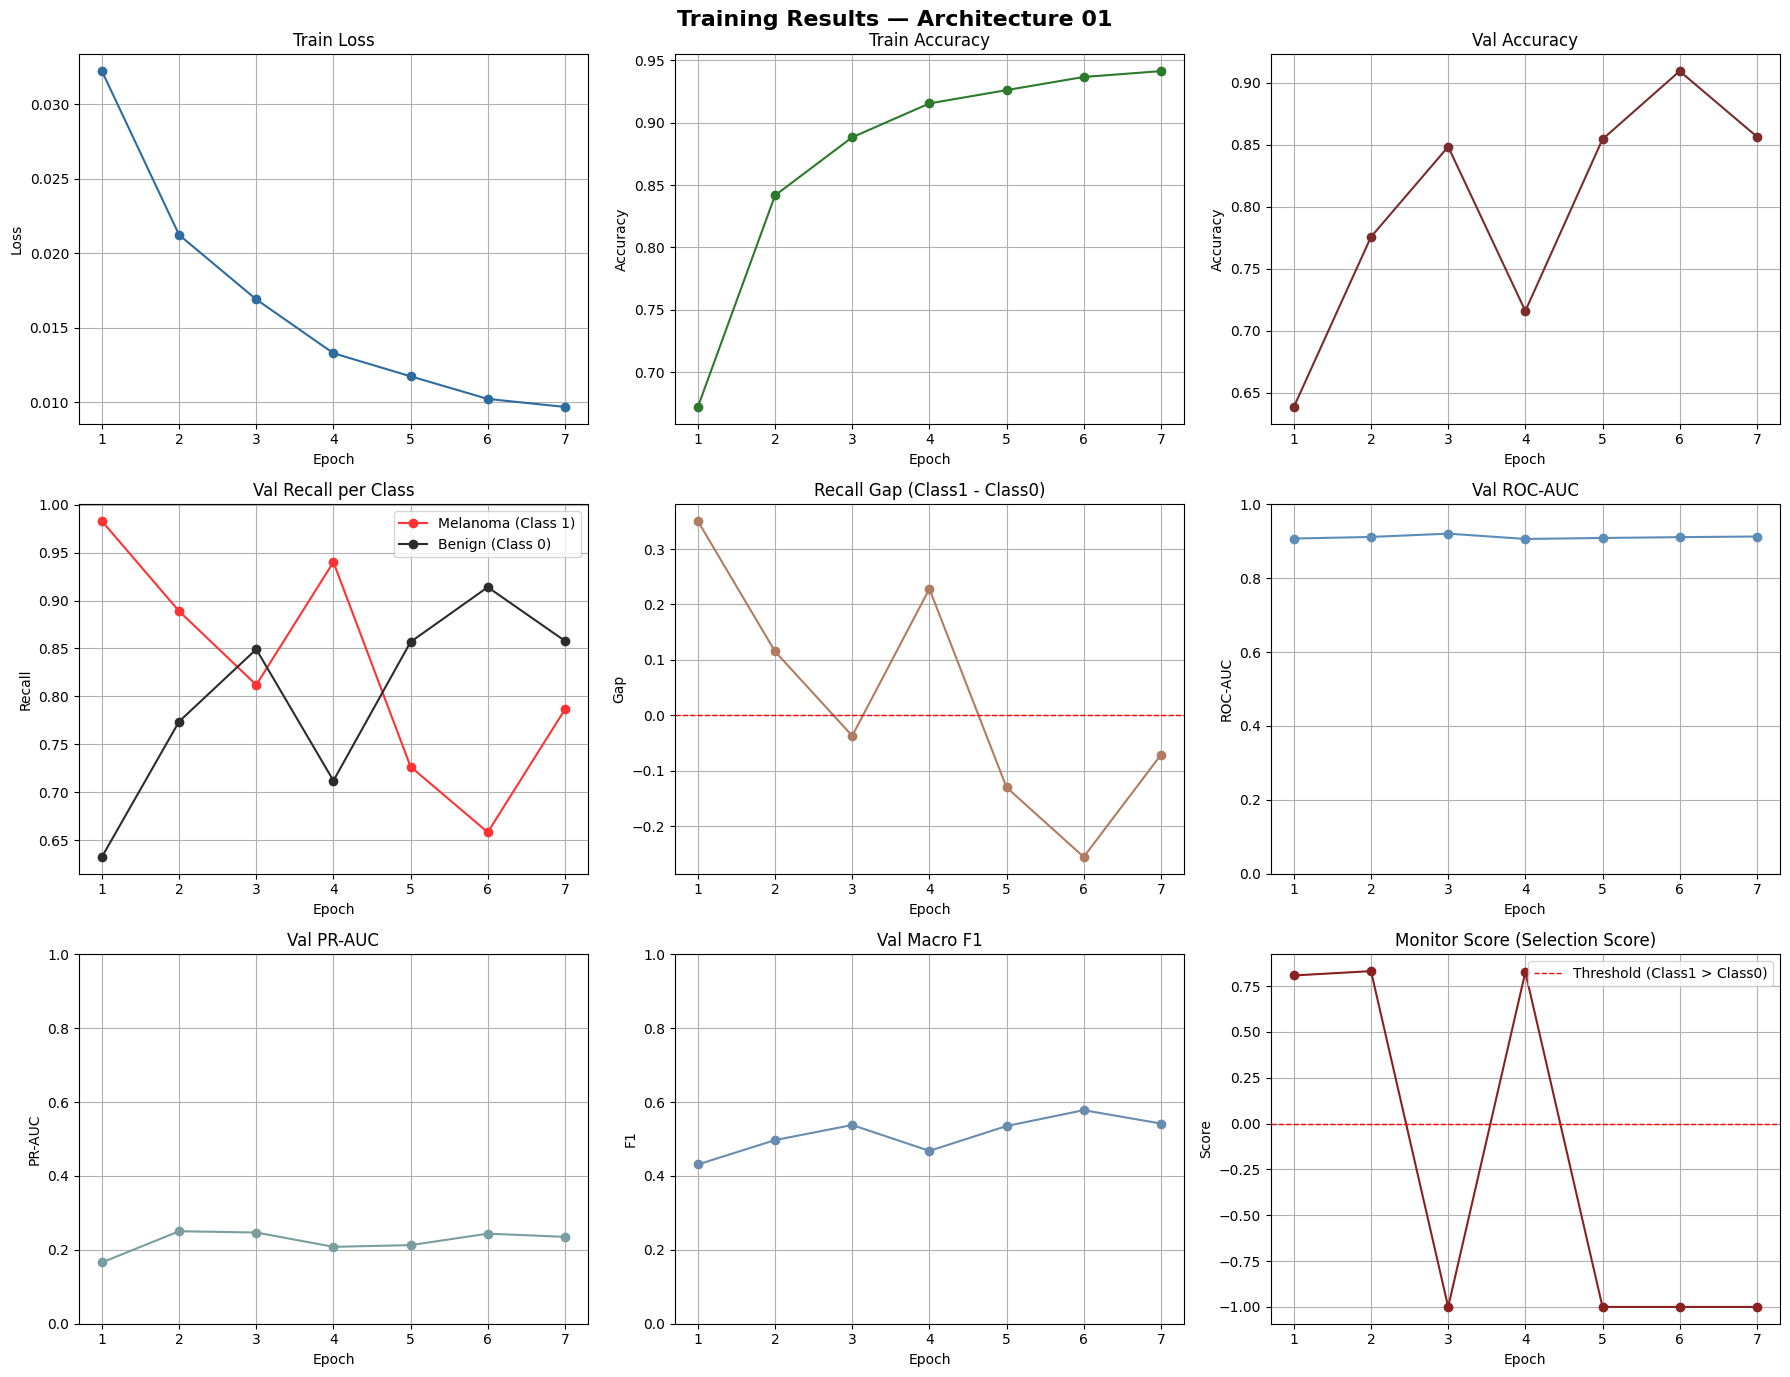

In [34]:
plot_training_results(results_s_arch01, arch_name="Architecture 01", save_path="/kaggle/working/training_results_arch01_img_only.png")

#### **Architecture 02:**

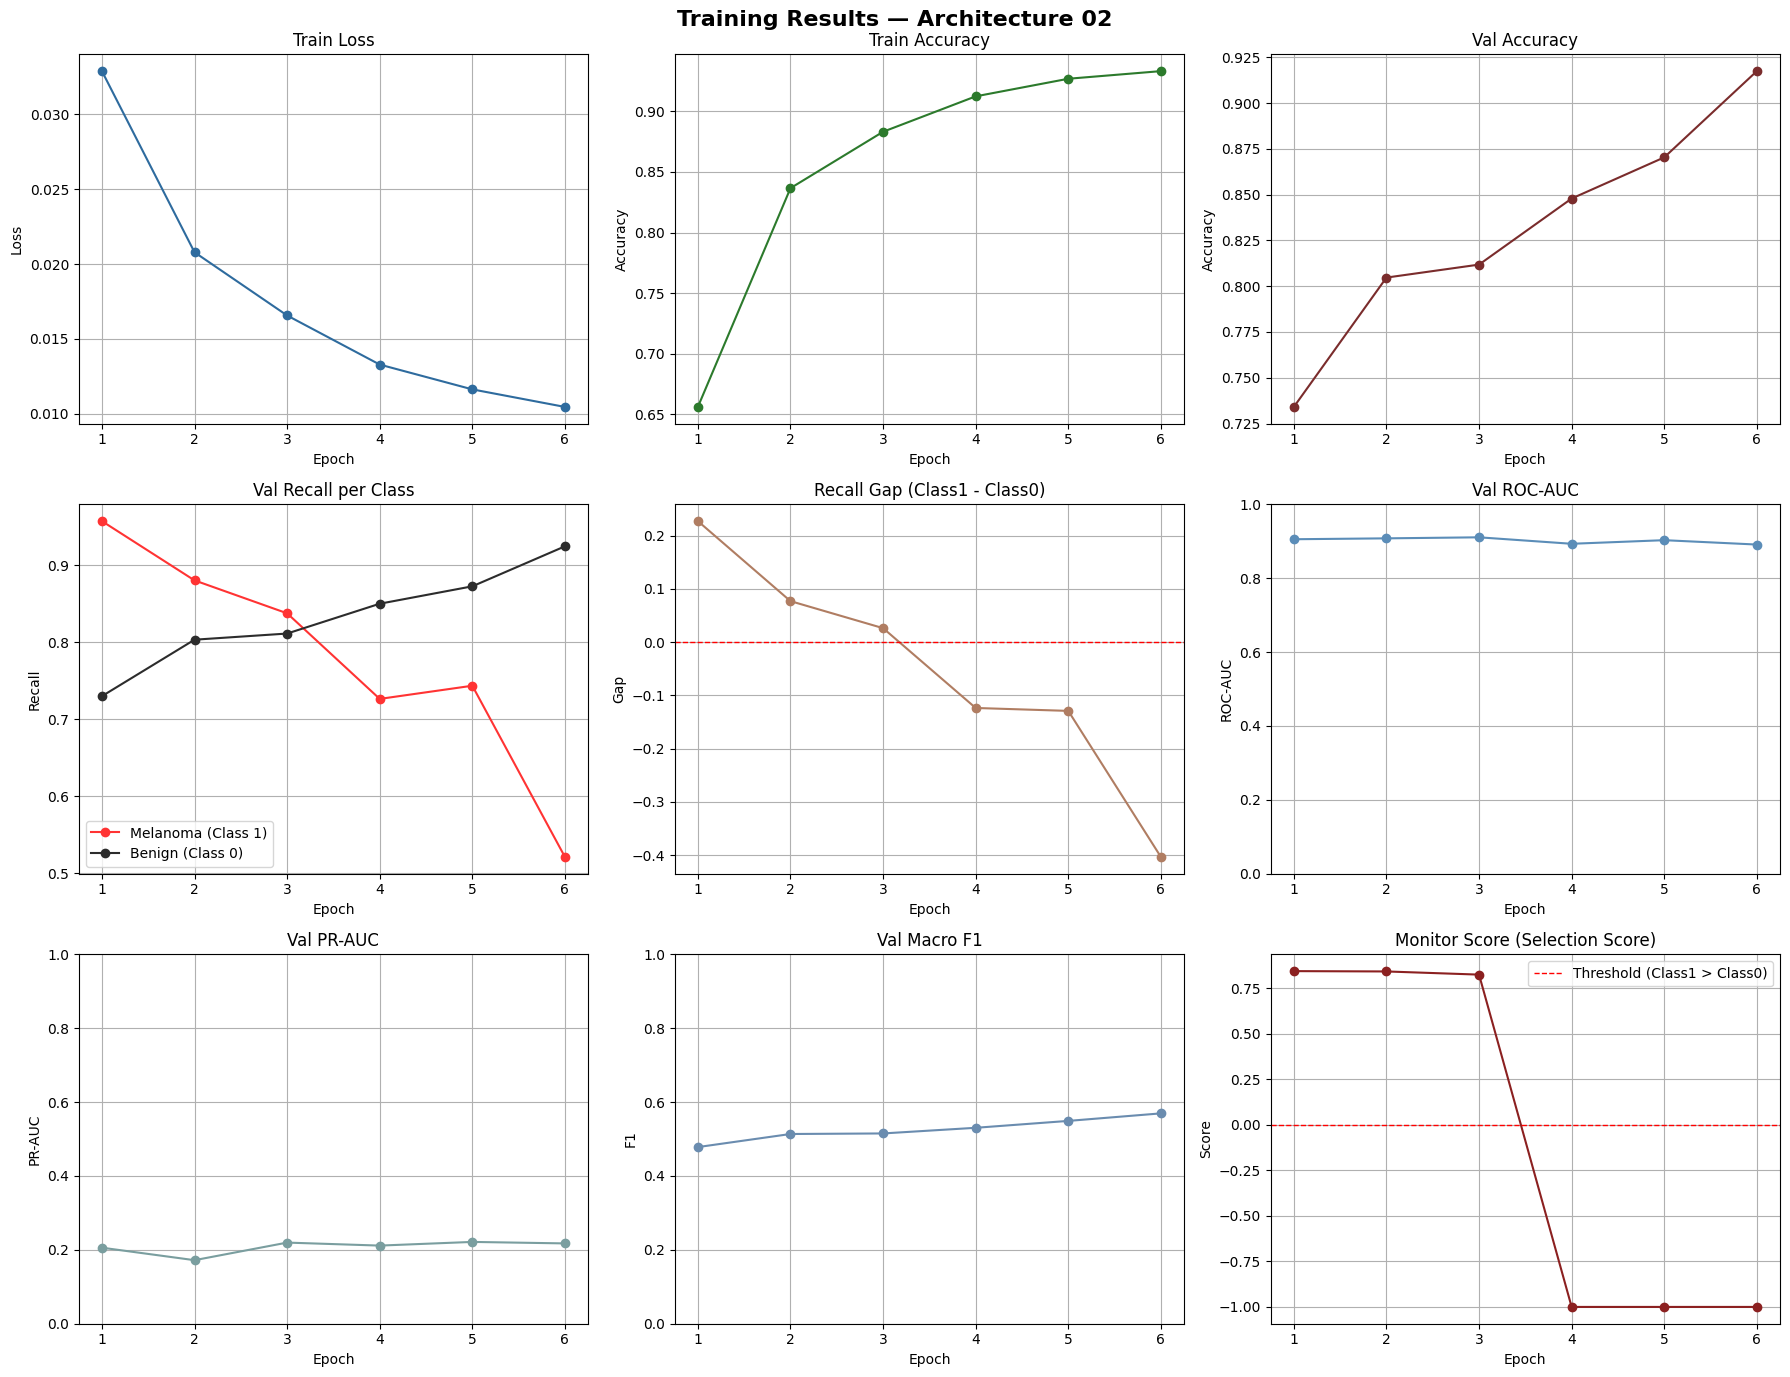

In [35]:
plot_training_results(results_s_arch02, arch_name="Architecture 02", save_path="/kaggle/working/training_results_arch02_img_only.png")

#### **Architecture 03:**

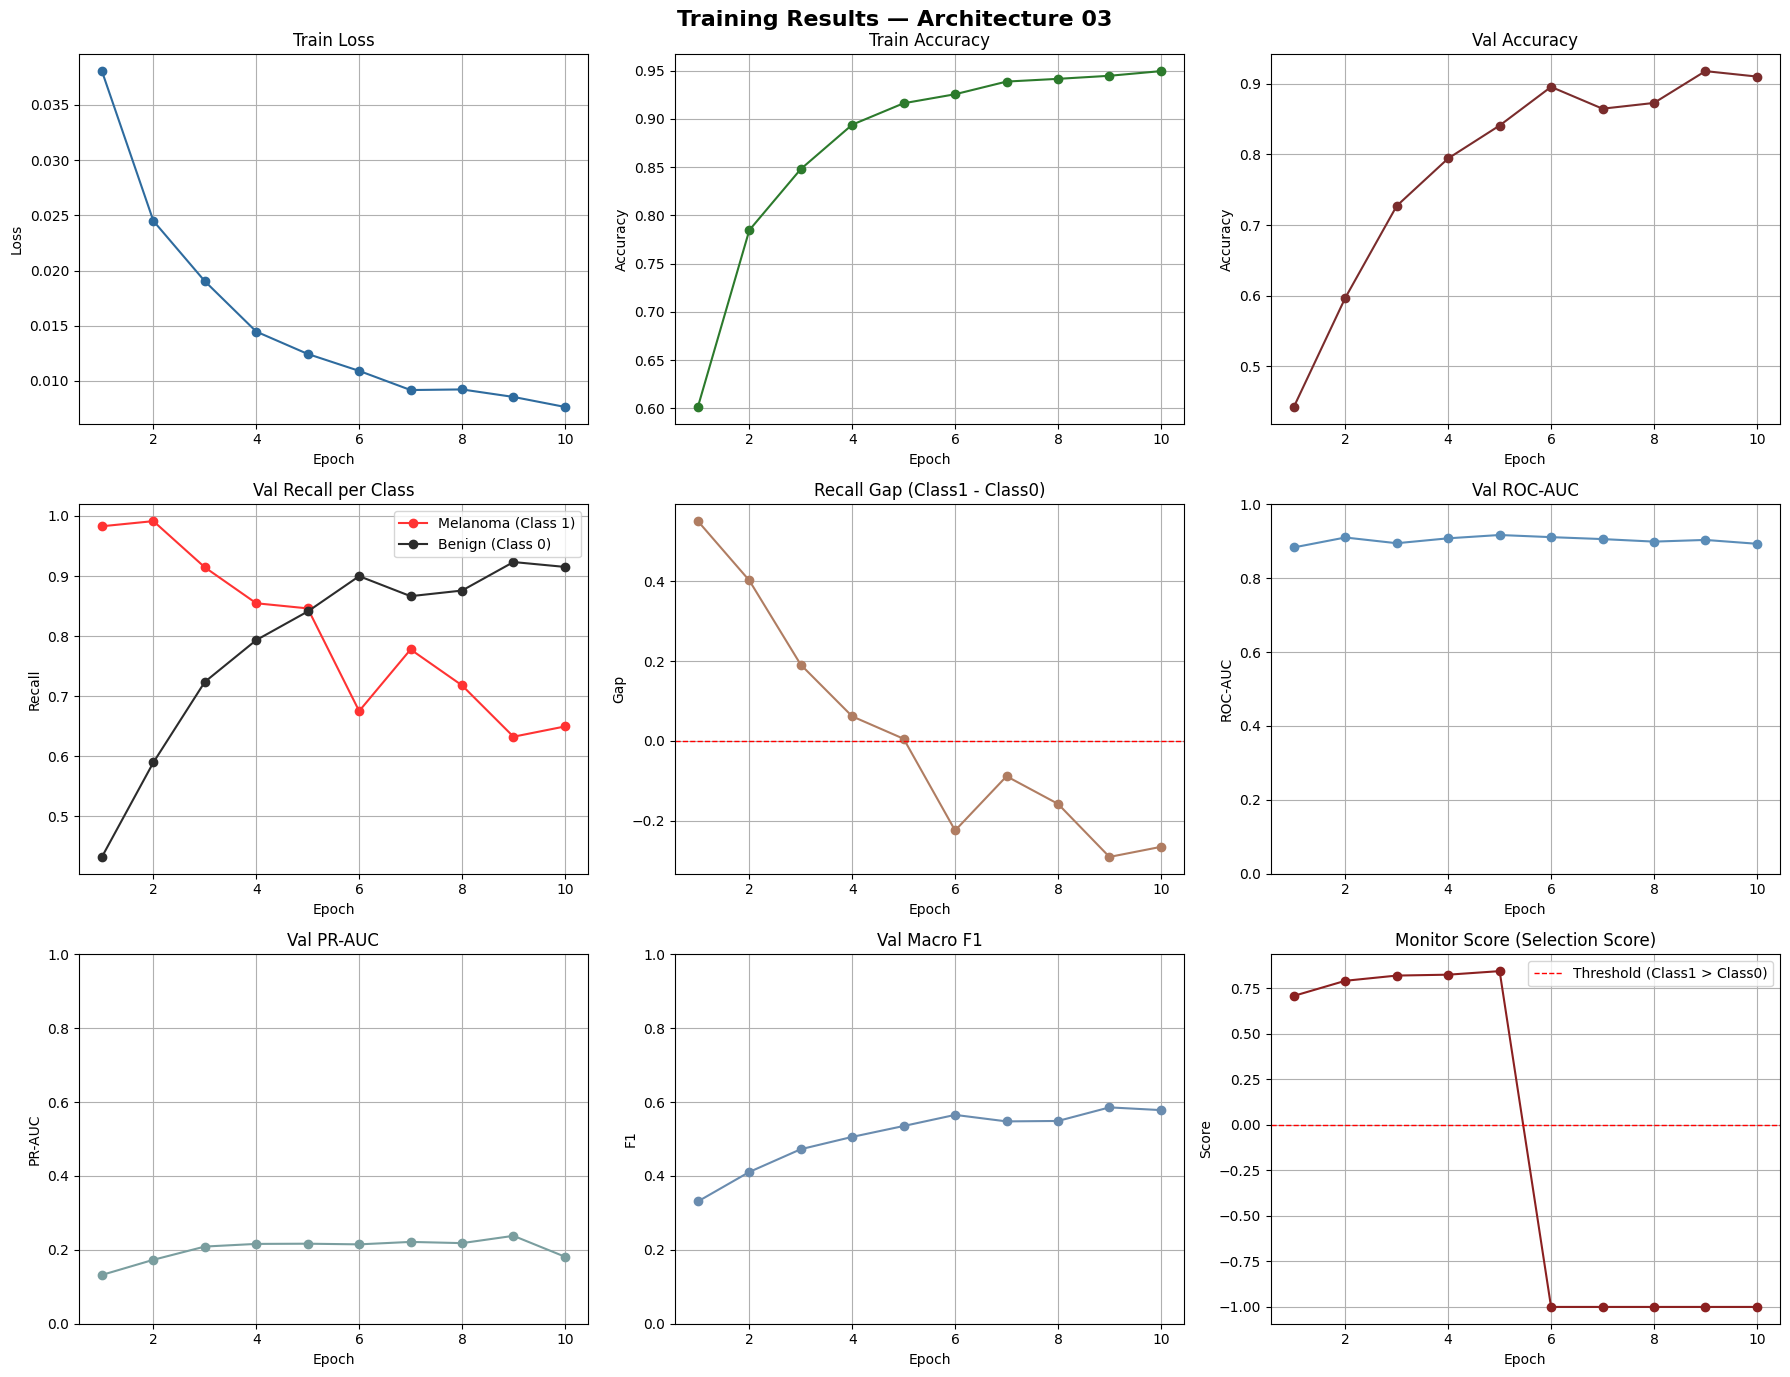

In [36]:
plot_training_results(results_s_arch03, arch_name="Architecture 03", save_path="/kaggle/working/training_results_arch01_img_only.png")

## 💠 **Compare All 3 Architectures For [ViT-S/14 - 22M]:** 

In [37]:
def plot_arch_comparison(histories, arch_names, metric="val_roc_auc", save_path=None):
    plt.figure(figsize=(10, 5))
    colors = ["#2E6B9E", "#8B2020", "#2C7A2C"]
    for history, name, color in zip(histories, arch_names, colors):
        epochs_range = range(1, len(history[metric]) + 1)
        plt.plot(epochs_range, history[metric],
                 marker="o", color=color, label=name)
    plt.title(f"Architecture Comparison — {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

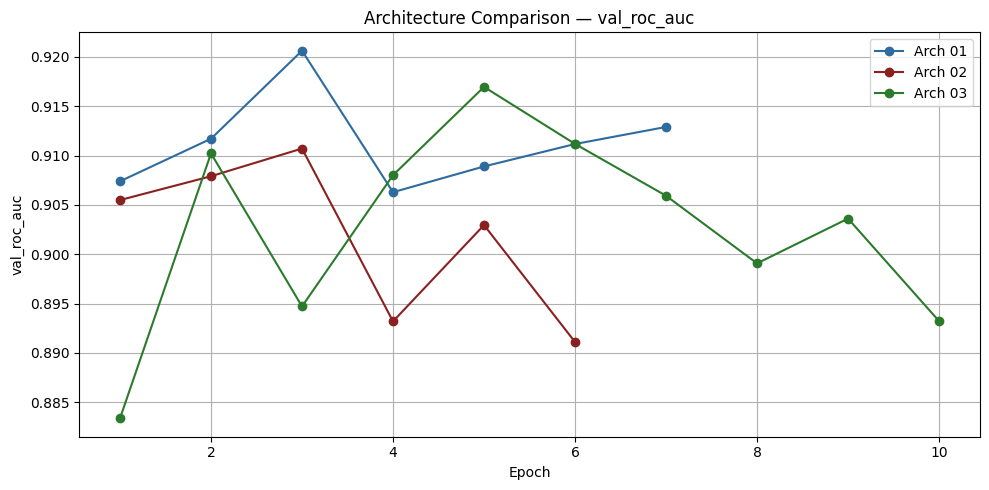

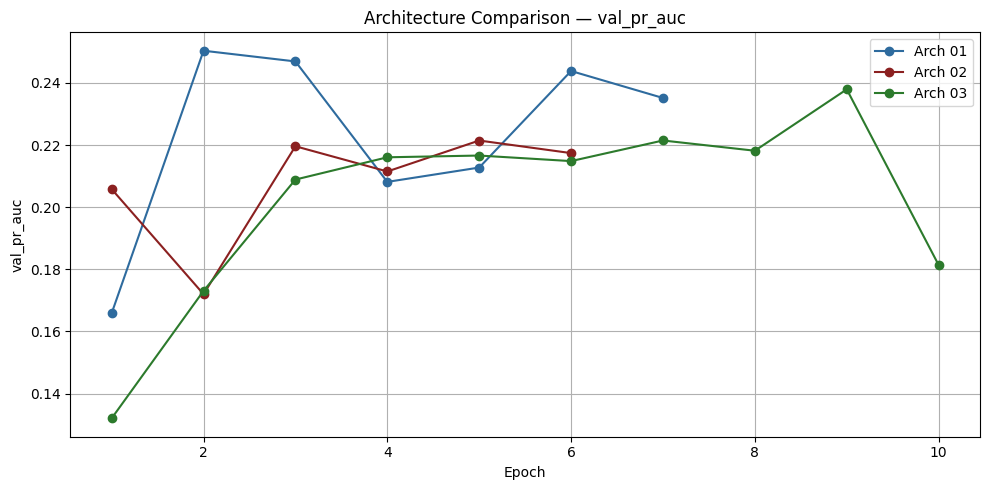

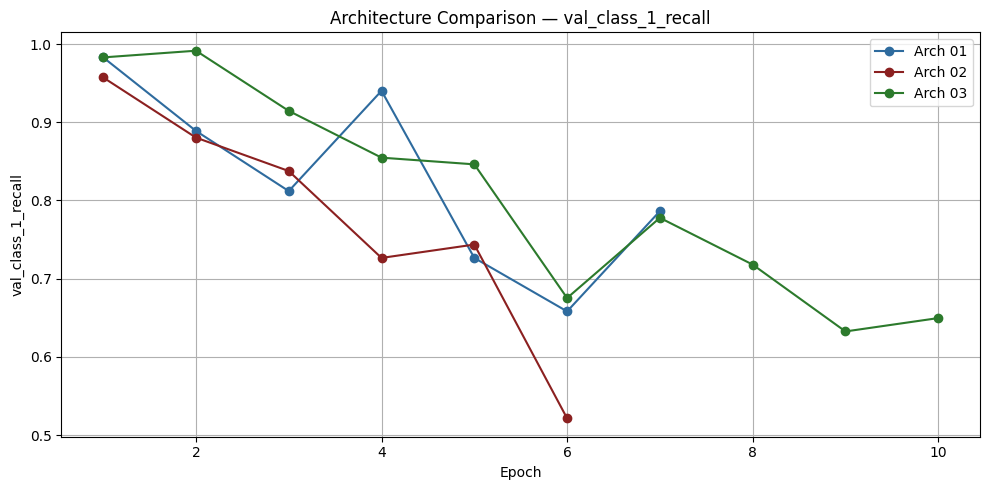

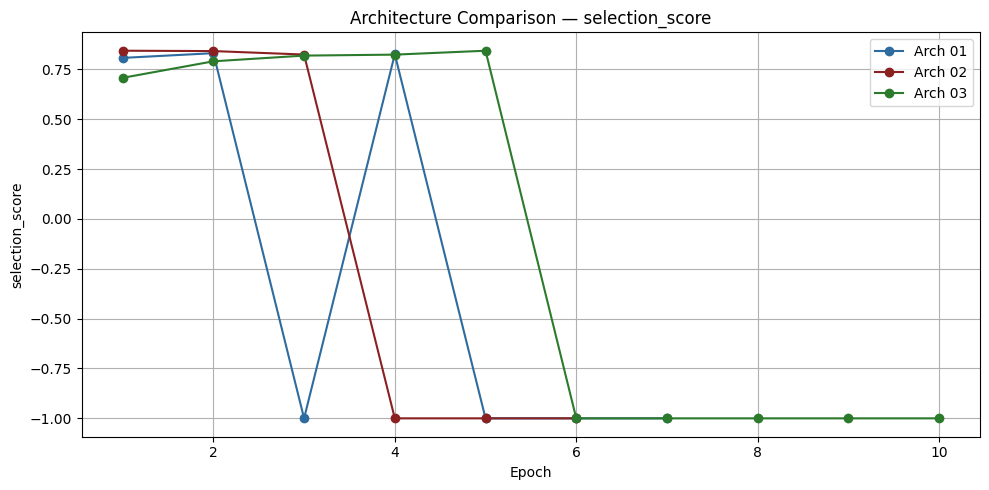

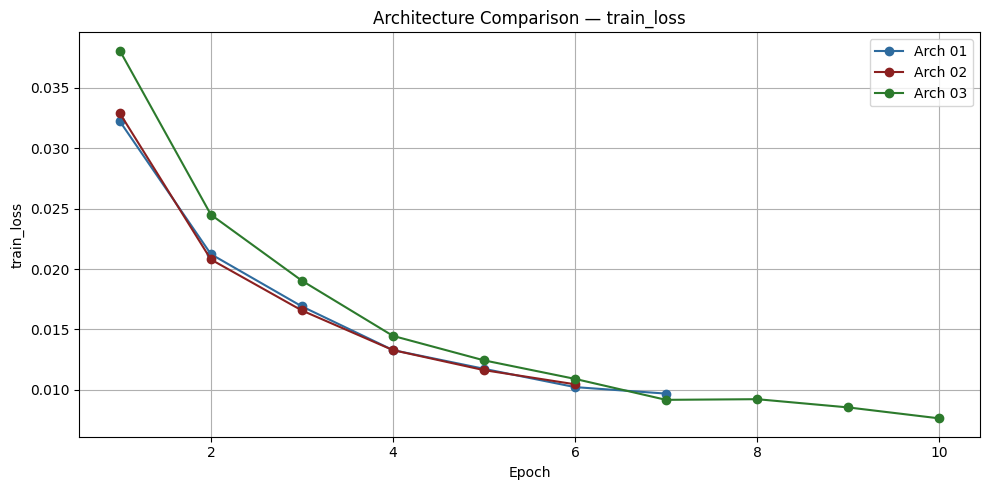

In [38]:
### Compare across all metrics for 
histories  = [results_s_arch01, results_s_arch02, results_s_arch03]
arch_names = ["Arch 01", "Arch 02", "Arch 03"]
plot_arch_comparison(histories, arch_names, metric="val_roc_auc", save_path="/kaggle/working/compare_roc_auc_img_only.png")
plot_arch_comparison(histories, arch_names, metric="val_pr_auc", save_path="/kaggle/working/compare_pr_auc_img_only.png")
plot_arch_comparison(histories, arch_names, metric="val_class_1_recall", save_path="/kaggle/working/compare_class1_recall_img_only.png")
plot_arch_comparison(histories, arch_names, metric="selection_score", save_path="/kaggle/working/compare_selection_score_img_only.png")
plot_arch_comparison(histories, arch_names, metric="train_loss", save_path="/kaggle/working/compare_train_loss_img_only.png")